In [4]:
%matplotlib widget

In [5]:
from applied.data_processing import (
    load_operating_data,
    load_product_data,
    compute_product_rate,
)

In [6]:
from pathlib import Path
import numpy as np

# --------------------------------------------------
# Load Data
# --------------------------------------------------

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

rate_df = compute_product_rate(op_df, prod_df)

In [7]:
op_df

,Date and time,Batch,LIQUID,LIQUID.1,LIQUID.2,LIQUID.3,LIQUID.4,LIQUID.5,pH,GAS,GAS.1,GAS.2,GAS.3,OFFGAS,OFFGAS.1,PRESSURE,PRESSURE.1,OXYGEN
2,2019-02-04 08:46:00,4030,1049.57,25.91,14.44,NaN,297.73,14980.0,5.76,NaN,NaN,NaN,55.14,1.87,16.94,1.79,5.15,6.78
3,2019-02-04 09:01:00,4030,1049.09,25.62,13.54,NaN,357.44,15000.0,5.79,NaN,NaN,NaN,56.88,1.89,20.52,1.80,5.16,8.39
4,2019-02-04 09:16:00,4030,1049.61,25.44,13.59,NaN,356.83,15010.0,5.80,NaN,NaN,NaN,56.03,1.94,23.77,1.80,5.15,8.07
5,2019-02-04 09:31:00,4030,1047.57,25.59,13.97,NaN,356.77,15000.0,5.79,NaN,NaN,NaN,53.91,2.00,27.01,1.80,5.15,7.23
6,2019-02-04 09:46:00,4030,1048.16,25.49,13.43,NaN,357.21,15010.0,5.78,NaN,NaN,NaN,53.97,2.05,30.15,1.80,5.13,7.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83201,2021-05-25 21:15:00,4053,889.62,0.02,0.01,0.0,0.14,12910.0,5.83,11668.37,33.20,39.50,0.00,0.72,4.46,2.00,5.11,113.78
83202,2021-05-25 21:20:00,4053,888.61,0.02,0.01,0.0,0.07,20210.0,5.72,11283.46,29.42,34.63,0.00,0.68,4.43,1.99,5.09,114.99
83203,2021-05-25 21:25:00,4053,890.29,0.02,0.01,0.0,0.09,20950.0,5.62,10838.39,26.67,30.97,0.00,0.65,4.49,1.99,5.07,115.00
83204,2021-05-25 21:30:00,4053,878.23,0.02,0.01,0.0,0.14,20960.0,5.53,10510.03,24.30,27.70,0.00,0.63,4.48,2.00,5.04,115.00


In [8]:
import pandas as pd

class BatchDataInspector:

    def __init__(self, df, time_col="Date and time", batch_col="Batch"):
        self.df = df.copy()
        self.time_col = time_col
        self.batch_col = batch_col

        self.df[self.time_col] = pd.to_datetime(self.df[self.time_col])

    # ---------- Basic dataset info ----------
    def shape(self):
        return self.df.shape

    def columns(self):
        return list(self.df.columns)

    # ---------- Batch info ----------
    def num_batches(self):
        return self.df[self.batch_col].nunique()

    def batch_names(self):
        return sorted(self.df[self.batch_col].unique())

    def rows_per_batch(self):
        return self.df.groupby(self.batch_col).size()

    # ---------- Date ranges ----------
    def global_date_range(self):
        return self.df[self.time_col].min(), self.df[self.time_col].max()

    def batch_date_ranges(self):
        return self.df.groupby(self.batch_col)[self.time_col].agg(["min", "max"])

    # ---------- Time resolution ----------
    def resolution(self):
        df = self.df.sort_values([self.batch_col, self.time_col])
        diffs = df.groupby(self.batch_col)[self.time_col].diff().dropna()
        return diffs.mode().iloc[0]

    def resolution_distribution(self):
        df = self.df.sort_values([self.batch_col, self.time_col])
        diffs = df.groupby(self.batch_col)[self.time_col].diff().dropna()
        mins = diffs.dt.total_seconds() / 60
        return mins.value_counts().sort_index()

    def resolution_percentage(self):
        dist = self.resolution_distribution()
        return (dist / dist.sum()) * 100

    # ---------- NaN statistics ----------
    def total_nans(self):
        return self.df.isna().sum().sum()

    def nans_per_column(self):
        return self.df.isna().sum()

    def nans_per_batch(self):
        return self.df.groupby(self.batch_col).apply(lambda x: x.isna().sum())

    # ---------- Data ranges ----------
    def column_ranges(self):
        numeric_cols = self.df.select_dtypes(include="number").columns
        return self.df[numeric_cols].agg(["min", "max"])

    def column_stats(self):
        return self.df.describe()

    # ---------- Batch duration ----------
    def batch_durations(self):
        g = self.df.groupby(self.batch_col)[self.time_col]
        return g.max() - g.min()

    # ---------- Quick summary ----------
    def summary(self):
        data = {
            "Metric": [
                "Rows",
                "Columns",
                "Number of batches",
                "Date start",
                "Date end",
                "Total NaNs",
            ],
            "Value": [
                len(self.df),
                len(self.df.columns),
                self.num_batches(),
                self.global_date_range()[0],
                self.global_date_range()[1],
                self.total_nans(),
            ],
        }

        return pd.DataFrame(data)

In [9]:
inspector = BatchDataInspector(op_df)

inspector.summary()

,Metric,Value
0,Rows,83204
1,Columns,18
2,Number of batches,22
3,Date start,2019-02-04 08:46:00
4,Date end,2021-05-25 21:35:00
5,Total NaNs,20897


In [10]:
import pandas as pd

def batch_timeseries_summary(df, time_col="Date and time", batch_col="Batch", value_col="LIQUID"):

    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values([batch_col, time_col])

    rows = []

    for batch, g in df.groupby(batch_col):

        start = g[time_col].min()
        end = g[time_col].max()

        diffs = g[time_col].diff().dropna()
        resolution = diffs.mode().iloc[0] if not diffs.empty else pd.NaT

        expected = pd.date_range(start=start, end=end, freq=resolution) if pd.notna(resolution) else []
        missing = len(expected) - len(g)

        rows.append({
            "Batch": batch,
            "start_time": start,
            "end_time": end,
            "duration": end - start,
            "resolution": resolution,
            "rows": len(g),
            "missing_timestamps": missing,
            "nan_values": g[value_col].isna().sum()
        })

    return pd.DataFrame(rows)

In [18]:
summary = batch_timeseries_summary(op_df)
summary

,Batch,start_time,end_time,duration,resolution,rows,missing_timestamps,nan_values
0,4030,2019-02-04 08:46:00,2019-03-08 08:16:00,31 days 23:30:00,0 days 00:15:00,3071,0,0
1,4032,2019-04-01 14:16:00,2019-05-03 06:31:00,31 days 16:15:00,0 days 00:15:00,3042,0,0
2,4033,2019-05-26 17:16:00,2019-06-23 20:01:00,28 days 02:45:00,0 days 00:15:00,2700,0,0
3,4034,2019-07-02 13:01:00,2019-08-03 23:46:00,32 days 10:45:00,0 days 00:15:00,3116,0,0
4,4035,2019-08-12 17:46:00,2019-09-08 23:46:00,27 days 06:00:00,0 days 00:15:00,2617,0,0
5,4036,2019-09-18 12:16:00,2019-10-20 23:46:00,32 days 11:30:00,0 days 00:15:00,3119,0,0
6,4037,2019-10-29 04:01:00,2019-11-20 14:31:00,22 days 10:30:00,0 days 00:15:00,2155,0,0
7,4038,2019-12-01 01:01:00,2019-12-30 15:31:00,29 days 14:30:00,0 days 00:15:00,2843,0,0
8,4039,2020-01-12 11:16:00,2020-01-30 23:46:00,18 days 12:30:00,0 days 00:15:00,1779,0,15
9,4040,2020-02-08 11:31:00,2020-03-08 04:01:00,28 days 16:30:00,0 days 00:15:00,2755,0,1


In [76]:
class BatchTimeSeriesPlotter:

    def __init__(self, df, time_col="Date and time", batch_col="Batch"):
        import pandas as pd

        self.df = df.copy()
        self.time_col = time_col
        self.batch_col = batch_col

        self.df[time_col] = pd.to_datetime(self.df[time_col])


    def _prepare_batch(self, batch, freq):
        import pandas as pd

        df_batch = self.df[self.df[self.batch_col] == batch].copy()
        df_batch = df_batch.sort_values(self.time_col)

        duplicate_times = df_batch.loc[
            df_batch[self.time_col].duplicated(keep=False),
            self.time_col
        ]

        df_batch = df_batch.groupby(self.time_col).mean(numeric_only=True)

        full_index = pd.date_range(
            start=df_batch.index.min(),
            end=df_batch.index.max(),
            freq=freq
        )

        missing_timestamps = full_index.difference(df_batch.index)

        df_batch = df_batch.reindex(full_index)

        return df_batch, duplicate_times, missing_timestamps


    def plot(self, batch=None, column=None, columns=None, batches=None, freq="15min"):
        import matplotlib.pyplot as plt
        import math

        # -------------------------------
        # MODE 1: batch → multiple columns
        # -------------------------------
        if batch is not None:

            df_batch, duplicate_times, missing_timestamps = self._prepare_batch(batch, freq)

            if columns is None:
                columns = [c for c in df_batch.columns if c != self.batch_col]

            if isinstance(columns, str):
                columns = [columns]

            n = len(columns)
            ncols = min(3, n)
            nrows = math.ceil(n / ncols)

            fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols,4*nrows), sharex=True)
            axes = axes if n == 1 else axes.flatten()

            for i, col in enumerate(columns):

                ax = axes[i]

                raw_series = df_batch[col]
                interp_series = raw_series.interpolate()

                ax.plot(df_batch.index, raw_series, color="black", alpha=0.7, linewidth=1,)

                nan_times = df_batch.index[df_batch[col].isna()]

                ax.scatter(nan_times,
                           interp_series.loc[nan_times],
                           color="orange", s=20)

                ax.scatter(missing_timestamps,
                           interp_series.reindex(missing_timestamps),
                           color="red", s=25)

                ax.scatter(duplicate_times,
                           interp_series.loc[duplicate_times],
                           color="green", s=25)

                ax.set_title(col)

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])

            fig.suptitle(f"Batch {batch}")
            plt.tight_layout()
            plt.show()


        # -------------------------------
        # MODE 2: column → multiple batches
        # -------------------------------
        elif column is not None:

            if batches is None:
                batches = sorted(self.df[self.batch_col].dropna().unique())

            if isinstance(batches, (int,float)):
                batches = [batches]

            n = len(batches)
            ncols = min(3, n)
            nrows = math.ceil(n / ncols)

            fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols,4*nrows))
            axes = axes if n == 1 else axes.flatten()

            for i, batch in enumerate(batches):

                ax = axes[i]

                df_batch, duplicate_times, missing_timestamps = self._prepare_batch(batch, freq)

                raw_series = df_batch[column]
                interp_series = raw_series.interpolate()

                ax.plot(df_batch.index, raw_series, color="black")

                nan_times = df_batch.index[df_batch[column].isna()]

                ax.scatter(nan_times,
                           interp_series.loc[nan_times],
                           color="orange", s=20)

                ax.scatter(missing_timestamps,
                           interp_series.reindex(missing_timestamps),
                           color="red", s=25)

                ax.scatter(duplicate_times,
                           interp_series.loc[duplicate_times],
                           color="green", s=25)

                ax.set_title(f"Batch {batch}")

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])

            fig.suptitle(column)
            plt.tight_layout()
            plt.show()

        else:
            raise ValueError("Provide either batch=... or column=...")

In [99]:
plotter = BatchTimeSeriesPlotter(op_df)

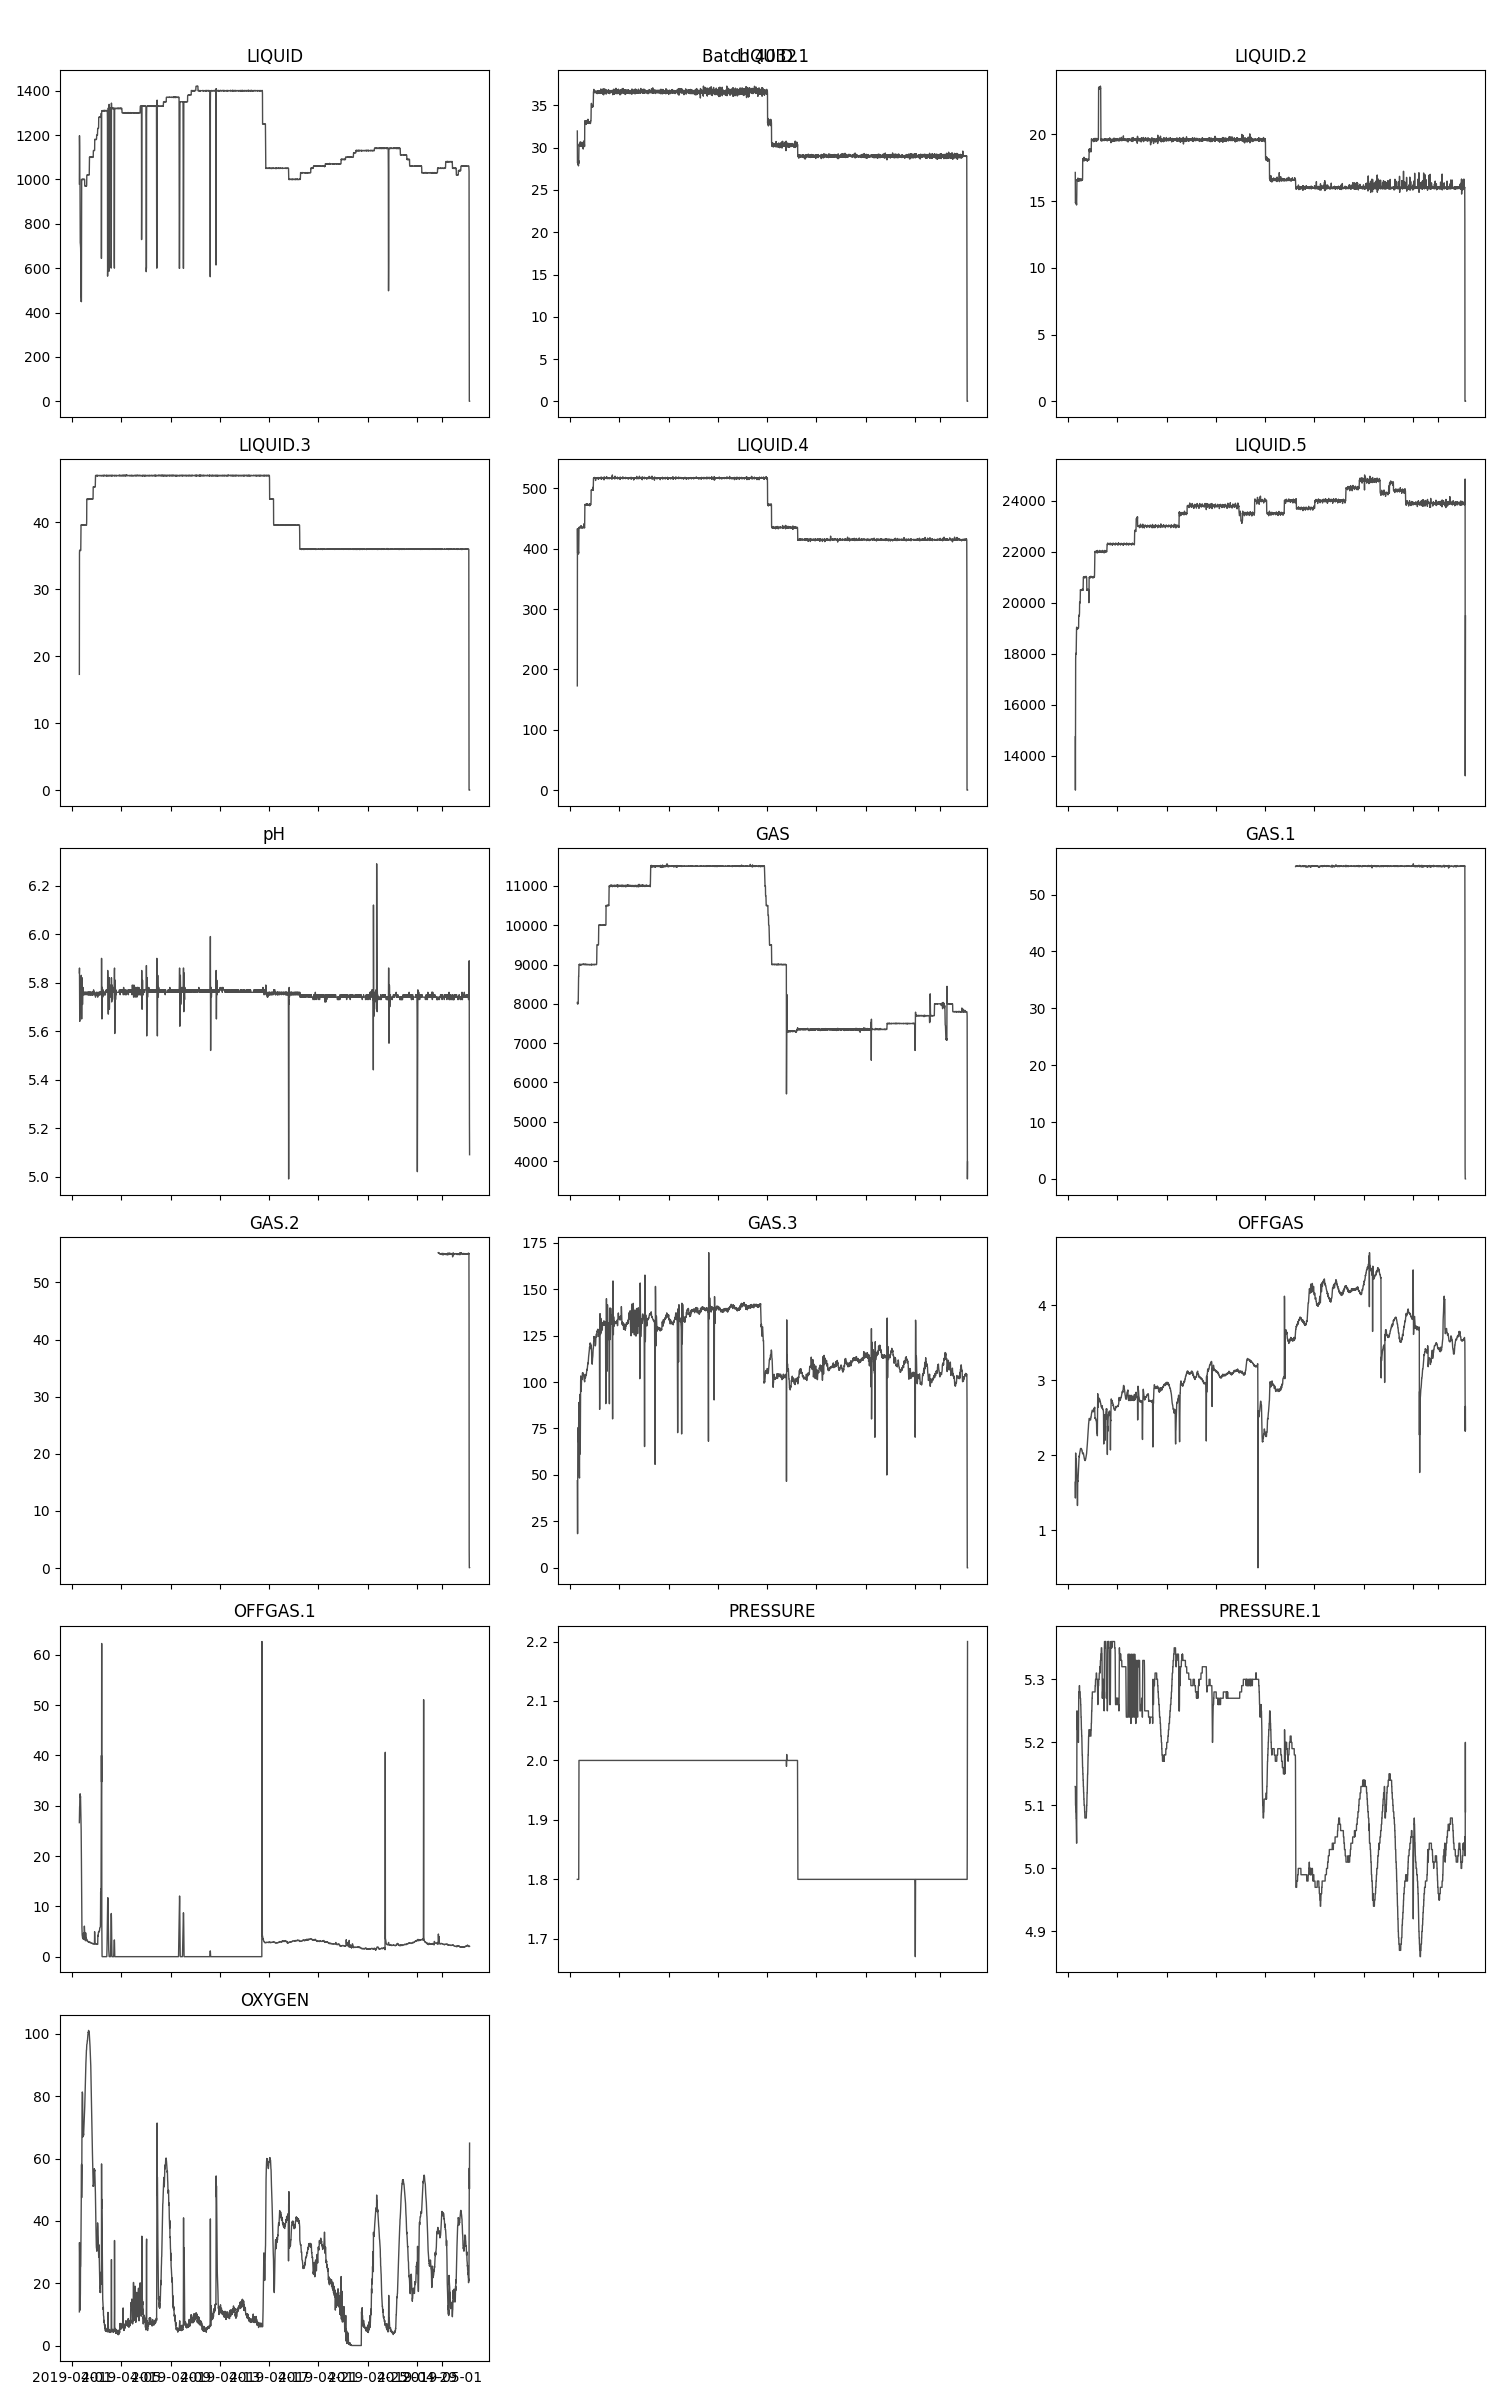

In [112]:
plotter.plot(batch=4032)

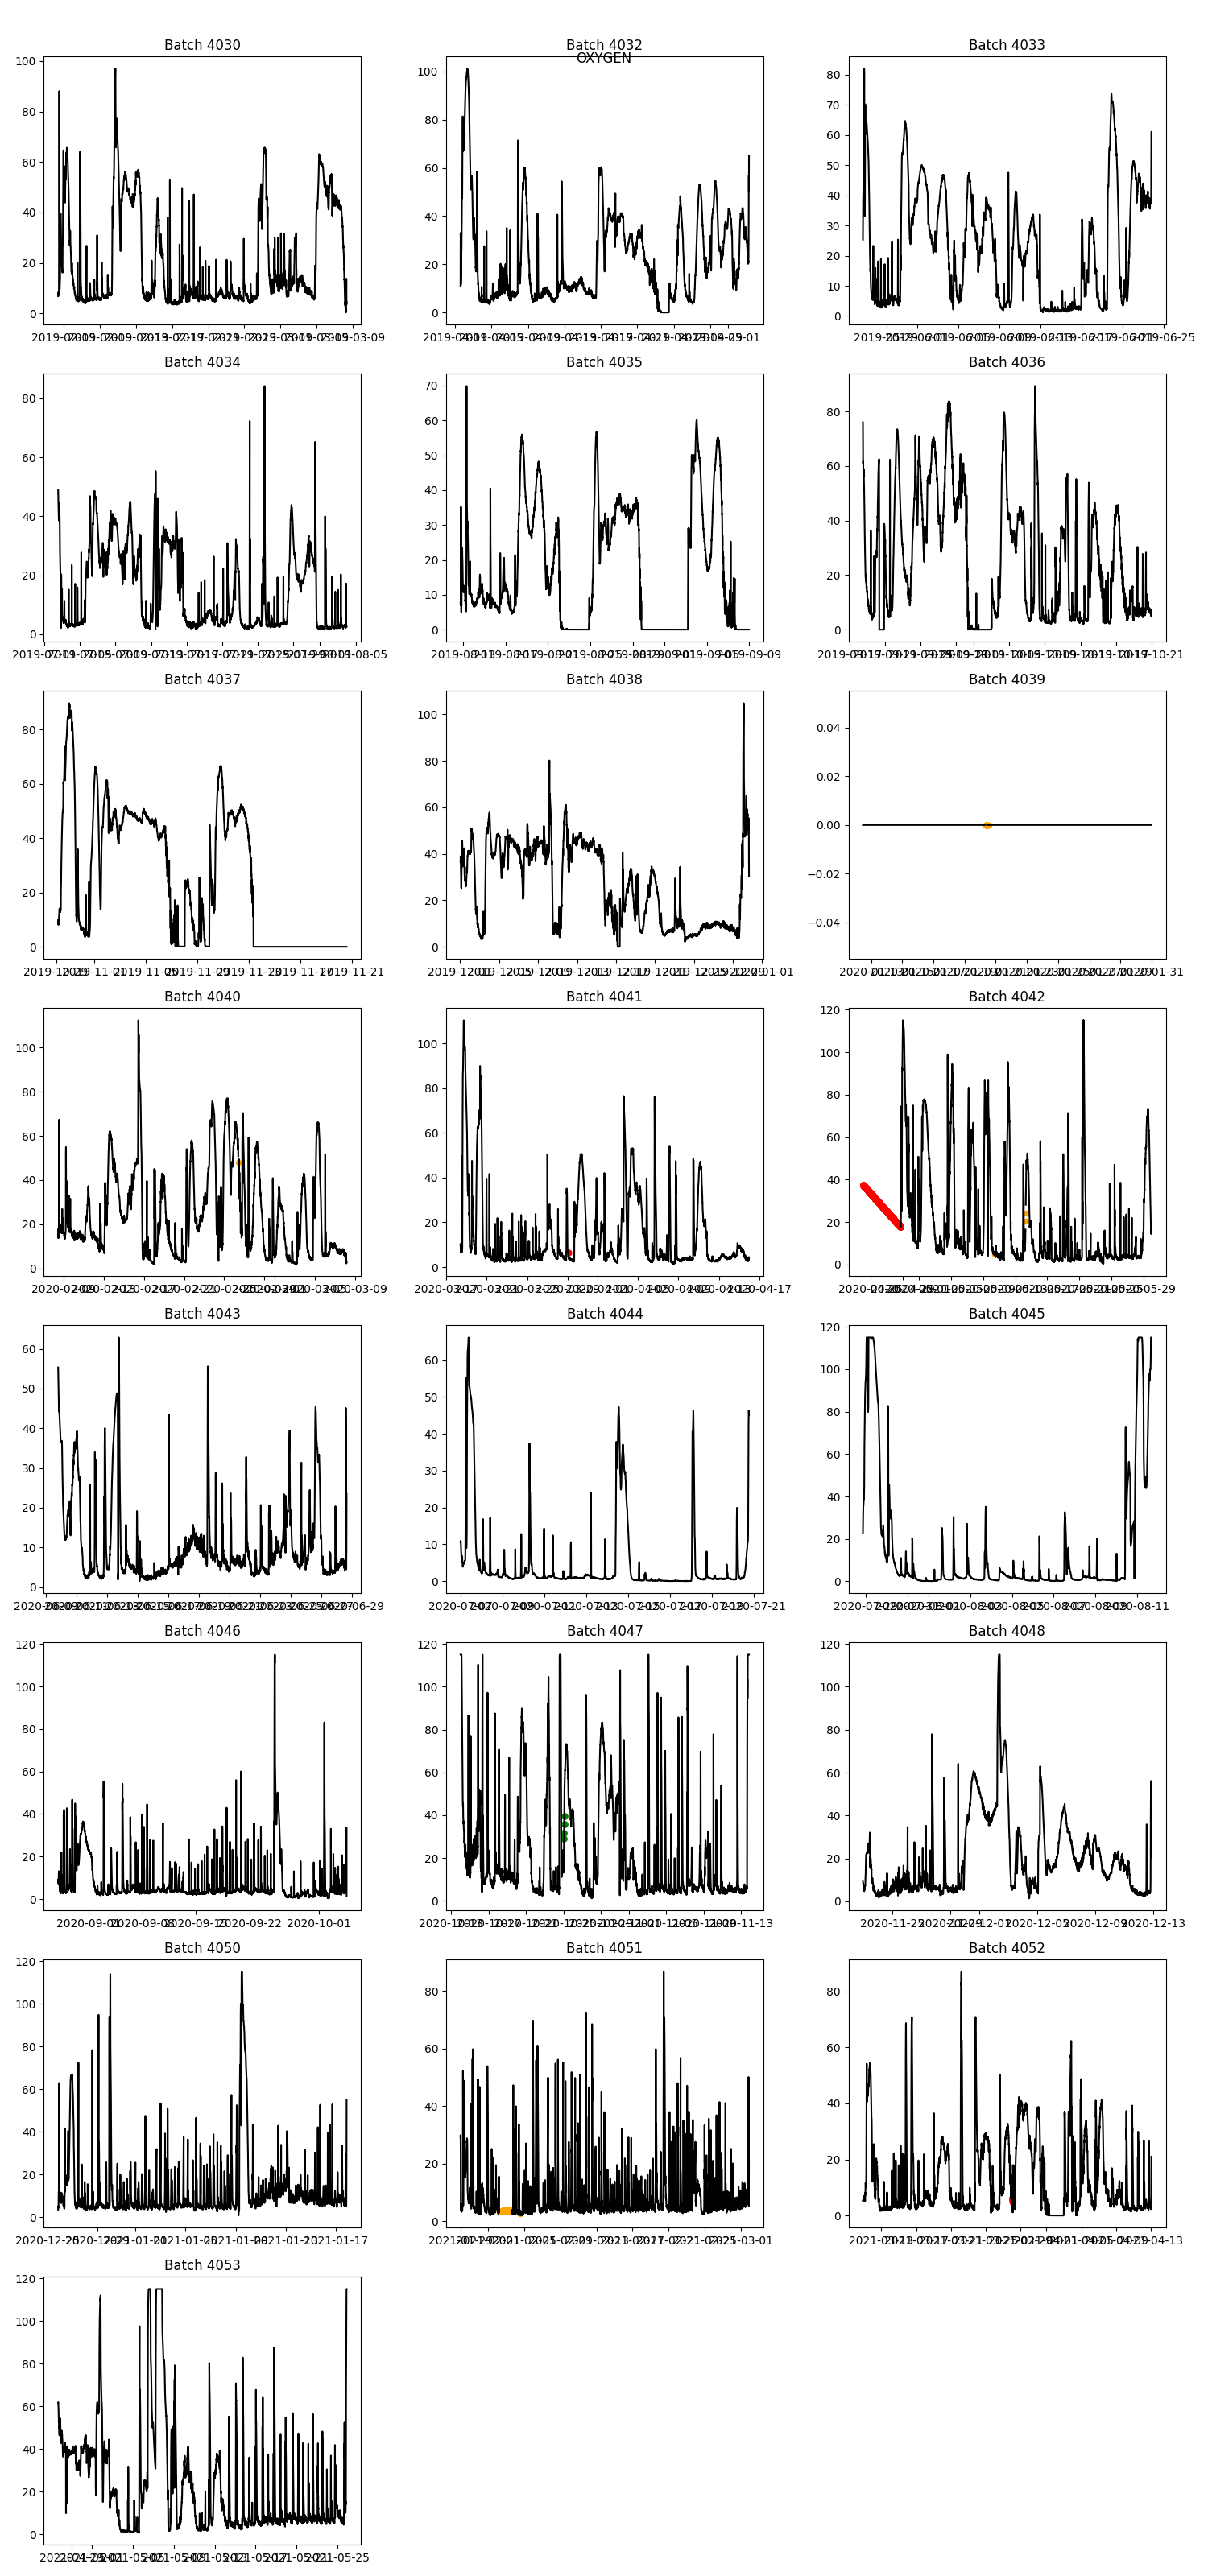

In [117]:
plotter.plot(column="OXYGEN")

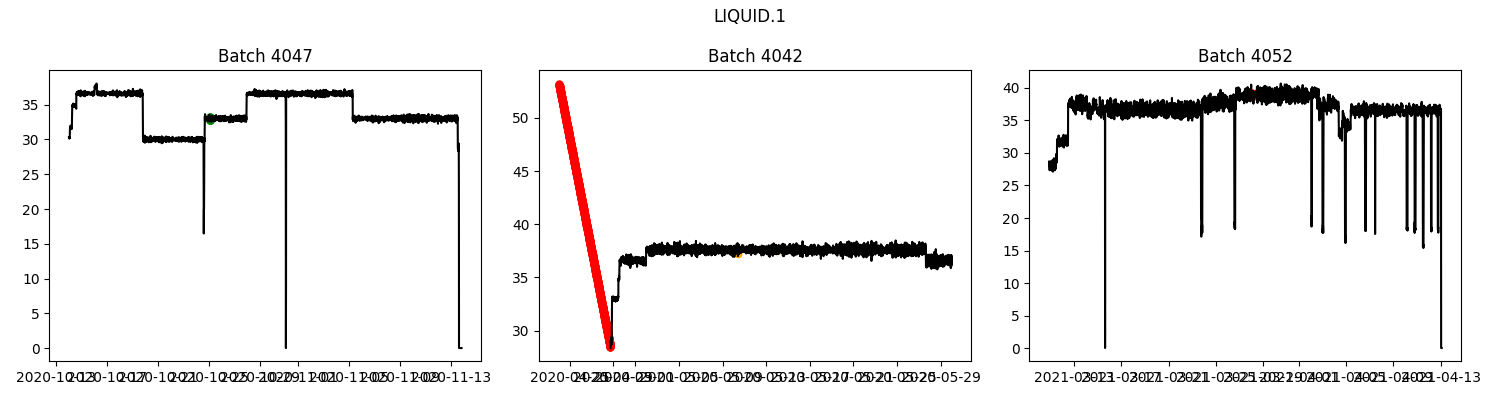

In [81]:
plotter.plot(column="LIQUID.1", batches=[4047,4042,4052])

In [101]:
def remove_sensor_spikes(
    df,
    batch,
    columns="LIQUID",
    time_col="Date and time",
    batch_col="Batch",
    max_delta=5,
    interp_limit=3
):

    import pandas as pd
    import numpy as np

    # allow single batch or list
    if isinstance(batch, (int, float)):
        batch = [batch]

    if isinstance(columns, str):
        columns = [columns]

    df_clean = df.copy()

    for b in batch:

        temp = df_clean[df_clean[batch_col] == b].copy()

        temp[time_col] = pd.to_datetime(temp[time_col])
        temp = temp.sort_values(time_col)

        for col in columns:

            series = temp[col]

            # two-sided spike detection
            delta_prev = series.diff().abs()
            delta_next = series.diff(-1).abs()

            spike_mask = (delta_prev > max_delta) & (delta_next > max_delta)

            temp.loc[spike_mask, col] = np.nan

            # interpolate only small gaps
            temp[col] = temp[col].interpolate(limit=interp_limit)

        df_clean = df_clean[df_clean[batch_col] != b]
        df_clean = pd.concat([df_clean, temp], ignore_index=True)

    return df_clean

In [110]:
from sktime.transformations.series.outlier_detection import HampelFilter
import pandas as pd
import numpy as np


def clean_liquid_sensor(
    df,
    batch,
    column="LIQUID.1",
    time_col="Date and time",
    batch_col="Batch"
):

    if isinstance(batch, (int, float)):
        batch = [batch]

    df_clean = df.copy()

    for b in batch:

        temp = df_clean[df_clean[batch_col] == b].copy()

        temp[time_col] = pd.to_datetime(temp[time_col])
        temp = temp.sort_values(time_col)
        temp = temp.set_index(time_col)

        # --- 1️⃣ spike removal ---
        hampel = HampelFilter(window_length=9, n_sigma=3)
        temp[column] = hampel.fit_transform(temp[column])

        # --- 2️⃣ dropout removal ---
        rolling_med = temp[column].rolling(20, center=True).median()

        dropout_mask = temp[column] < (rolling_med - 8)

        temp.loc[dropout_mask, column] = np.nan

        # --- 3️⃣ interpolate ---
        temp[column] = temp[column].interpolate(limit=5)

        temp = temp.reset_index()

        df_clean = df_clean[df_clean[batch_col] != b]
        df_clean = pd.concat([df_clean, temp], ignore_index=True)

    return df_clean

In [108]:
op_df_cleaned = clean_sensor_hampel(
    op_df,
    batch=[4047,4042,4052],
    column="LIQUID.1"
)

c:\Users\richa\Desktop\Applied\.venv\lib\site-packages\sktime\transformations\series\outlier_detection.py:96: UserWarning: Series contains nan values, more nan might be
                added if there are outliers
  return self._transform_series(Z)


In [102]:
op_df_cleaned = remove_sensor_spikes(
    op_df,
    batch=[4047,4042,4052],
    columns=["LIQUID.1"],
    max_delta=5
)

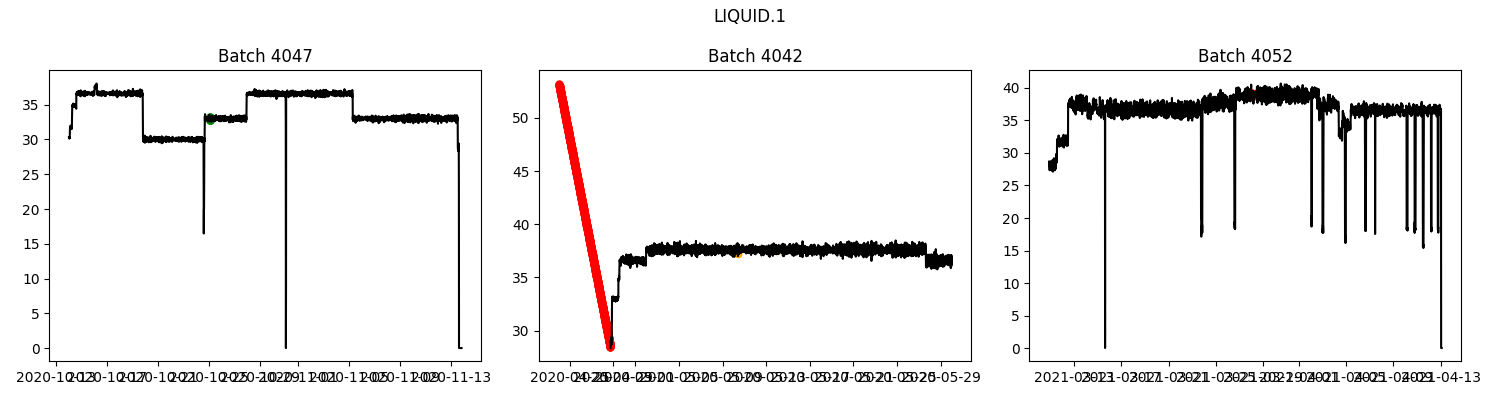

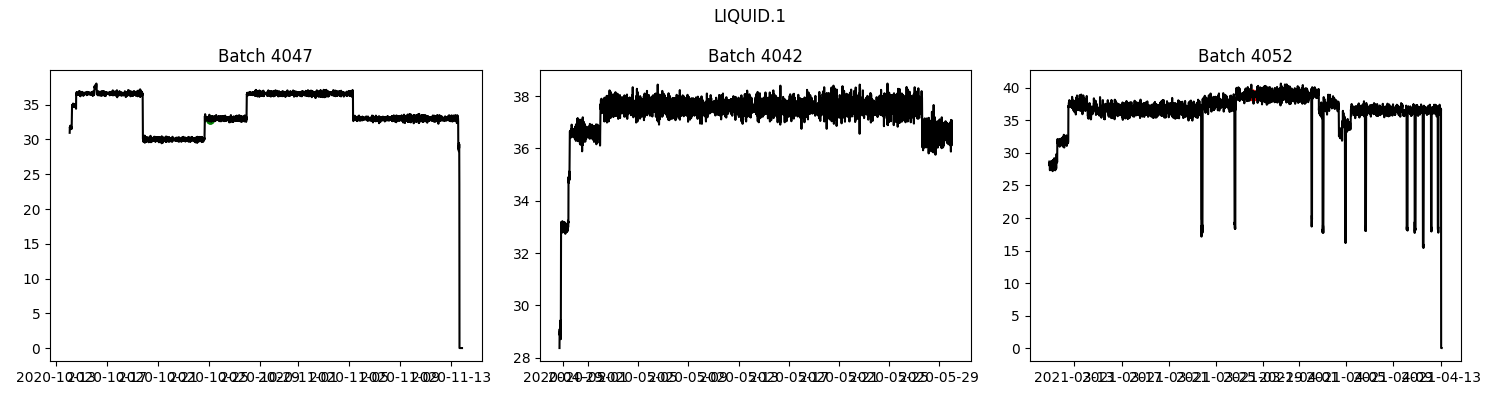

In [109]:
plotter_cleaned = BatchTimeSeriesPlotter(op_df_cleaned)


plotter.plot(column="LIQUID.1", batches=[4047,4042,4052])
plotter_cleaned.plot(column="LIQUID.1", batches=[4047,4042,4052])

In [106]:
def plot_rate_histogram(
    df,
    column,
    bins=100,
    time_col=None
):
    import matplotlib.pyplot as plt

    temp = df.copy()

    if time_col is not None:
        temp = temp.sort_values(time_col)

    rate = temp[column].diff().dropna()

    plt.figure()

    plt.hist(rate, bins=bins)

    plt.title(f"Rate of Change of {column}")
    plt.xlabel(f"Δ {column}")
    plt.ylabel("Frequency")

    plt.show()

In [112]:
def detect_time_gaps(
    df,
    batch,
    column=None,
    time_col="Date and time",
    batch_col="Batch",
    freq="15min"
):

    import pandas as pd

    df_batch = df[df[batch_col] == batch].copy()
    df_batch[time_col] = pd.to_datetime(df_batch[time_col])
    df_batch = df_batch.sort_values(time_col)
    df_batch = df_batch.set_index(time_col)

    series_start = df_batch.index.min()
    series_end = df_batch.index.max()

    full_index = pd.date_range(
        start=series_start,
        end=series_end,
        freq=freq
    )

    missing_timestamps = full_index.difference(df_batch.index)

    # --- Missing timestamp gaps ---
    missing_series = pd.Series(missing_timestamps)

    if len(missing_series) > 0:

        gap_id = (missing_series.diff() != pd.Timedelta(freq)).cumsum()

        gap_bounds = (
            missing_series.groupby(gap_id)
            .agg(first="first", last="last", n_missing="size")
        )

        gap_bounds["duration"] = (
            gap_bounds["last"] - gap_bounds["first"] + pd.Timedelta(freq)
        )

    else:
        gap_bounds = pd.DataFrame(columns=["first", "last", "n_missing", "duration"])

    gap_bounds["batch"] = batch
    gap_bounds["gap_type"] = "missing_timestamp"

    results = [gap_bounds]

    # --- NaN gaps (optional) ---
    if column is not None:

        nan_times = df_batch.index[df_batch[column].isna()]
        nan_series = pd.Series(nan_times)

        if len(nan_series) > 0:

            nan_gap_id = (nan_series.diff() != pd.Timedelta(freq)).cumsum()

            nan_bounds = (
                nan_series.groupby(nan_gap_id)
                .agg(first="first", last="last", n_missing="size")
            )

            nan_bounds["duration"] = (
                nan_bounds["last"] - nan_bounds["first"] + pd.Timedelta(freq)
            )

            nan_bounds["batch"] = batch
            nan_bounds["gap_type"] = f"{column}_nan"

            results.append(nan_bounds)

    result_df = pd.concat(results, ignore_index=True)

    return result_df

def detect_time_gaps_all_columns(
    df,
    batch,
    time_col="Date and time",
    batch_col="Batch",
    freq="15min"
):

    sensor_cols = df.columns.drop([time_col, batch_col])

    results = []

    for col in sensor_cols:

        gap_df = detect_time_gaps(
            df,
            batch=batch,
            column=col,
            time_col=time_col,
            batch_col=batch_col,
            freq=freq
        )

        if not gap_df.empty:
            gap_df["column"] = col
            results.append(gap_df)

    if len(results) == 0:
        return pd.DataFrame()

    return pd.concat(results, ignore_index=True)

In [114]:
# detect_time_gaps_all_columns(op_df, batch=4051, freq="5min")

### Handling Missing Values – Batch 4039

For **Batch 4039**, the `LIQUID` signal contained **15 missing values (NaNs)**.  
These missing observations were filled using **linear interpolation**.

Interpolation was chosen because:

- The number of missing points was **very small relative to the total batch length** (~1779 observations).
- The missing values were **isolated and short-lived**, rather than long continuous gaps.
- The `LIQUID` signal changes **smoothly over time**, making interpolation a reasonable estimate of the underlying process.
- The goal was to **preserve the original process dynamics** without introducing artificial smoothing or removing legitimate process behaviour.

Using interpolation allows the signal to remain **continuous for analysis and modelling**, while making minimal assumptions about the missing values.

The interpolation was applied only to the `LIQUID` variable for **Batch 4039**, leaving all other batches unchanged.

```python
df_batch["LIQUID"] = df_batch["LIQUID"].interpolate()

In [ ]:
def interpolate_batch(df, batch, columns="LIQUID"):

    if isinstance(columns, str):
        columns = [columns]

    temp = df[df["Batch"] == batch].copy()

    temp["Date and time"] = pd.to_datetime(temp["Date and time"])
    temp = temp.sort_values("Date and time")

    for col in columns:
        temp[col] = temp[col].interpolate()

    df_no_batch = df[df["Batch"] != batch]

    df_clean = pd.concat([df_no_batch, temp], ignore_index=True)

    return df_clean


def interpolate_missing_timestamps(df, batch, columns="LIQUID", freq="15min"):

    if isinstance(columns, str):
        columns = [columns]

    temp = df[df["Batch"] == batch].copy()

    temp["Date and time"] = pd.to_datetime(temp["Date and time"])
    temp = temp.sort_values("Date and time")
    temp = temp.set_index("Date and time")

    full_index = pd.date_range(
        start=temp.index.min(),
        end=temp.index.max(),
        freq=freq
    )

    temp = temp.reindex(full_index)

    temp["Batch"] = batch

    for col in columns:
        temp[col] = temp[col].interpolate()

    temp = temp.reset_index().rename(columns={"index": "Date and time"})

    df_no_batch = df[df["Batch"] != batch]

    df_clean = pd.concat([df_no_batch, temp], ignore_index=True)

    return df_clean


def fix_batch_duplicates(df, batch, columns="LIQUID"):

    if isinstance(columns, str):
        columns = [columns]

    temp = df[df["Batch"] == batch].copy()

    temp["Date and time"] = pd.to_datetime(temp["Date and time"])
    temp = temp.sort_values("Date and time")

    # collapse duplicate timestamps
    temp = temp.groupby("Date and time").mean(numeric_only=True)

    temp["Batch"] = batch

    for col in columns:
        temp[col] = temp[col].interpolate()

    temp = temp.reset_index()

    df_no_batch = df[df["Batch"] != batch]

    df_clean = pd.concat([df_no_batch, temp], ignore_index=True)

    return df_clean

# -------------------------------------------------
# CLEANING PIPELINE
# -------------------------------------------------

op_df_cleaned = op_df.copy()

# normal interpolation
op_df_cleaned = interpolate_batch(op_df_cleaned, 4039)
op_df_cleaned = interpolate_batch(op_df_cleaned, 4040)


# missing timestamps
op_df_cleaned = interpolate_missing_timestamps(op_df_cleaned, 4041)
op_df_cleaned = interpolate_missing_timestamps(op_df_cleaned, 4052)

# duplicate timestamps
op_df_cleaned = fix_batch_duplicates(op_df_cleaned, 4047)

In [ ]:
def clean_batch(
    df,
    batch,
    columns=None,
    time_col="Date and time",
    batch_col="Batch",
):

    import pandas as pd

    temp = df[df[batch_col] == batch].copy()

    temp[time_col] = pd.to_datetime(temp[time_col])
    temp = temp.sort_values(time_col)
    temp = temp.set_index(time_col)

    if columns is None:
        columns = [c for c in temp.columns if c != batch_col]

    if isinstance(columns, str):
        columns = [columns]

    # collapse duplicates
    temp = temp.groupby(level=0).mean(numeric_only=True)

    # detect resolution
    resolution = temp.index.to_series().diff().mode()[0]

    full_index = pd.date_range(
        start=temp.index.min(),
        end=temp.index.max(),
        freq=resolution
    )

    temp = temp.reindex(full_index)

    temp[batch_col] = batch

    for col in columns:
        if col in temp.columns:
            temp[col] = temp[col].interpolate()

    temp = temp.reset_index().rename(columns={"index": time_col})

    df_no_batch = df[df[batch_col] != batch]

    return pd.concat([df_no_batch, temp], ignore_index=True)


def clean_all_batches(
    df,
    columns=None,
    time_col="Date and time",
    batch_col="Batch"
):

    df_clean = df.copy()

    for batch in df_clean[batch_col].dropna().unique():
        df_clean = clean_batch(
            df_clean,
            batch,
            columns=columns,
            time_col=time_col,
            batch_col=batch_col
        )

    return df_clean

In [108]:
op_df_cleaned = clean_all_batches(op_df)


In [109]:
summary = batch_timeseries_summary(op_df_cleaned)
print(summary[(summary["missing_timestamps"] != 0) | (summary["nan_values"] != 0)])

Empty DataFrame
Columns: [Batch, start_time, end_time, duration, resolution, rows, missing_timestamps, nan_values]
Index: []


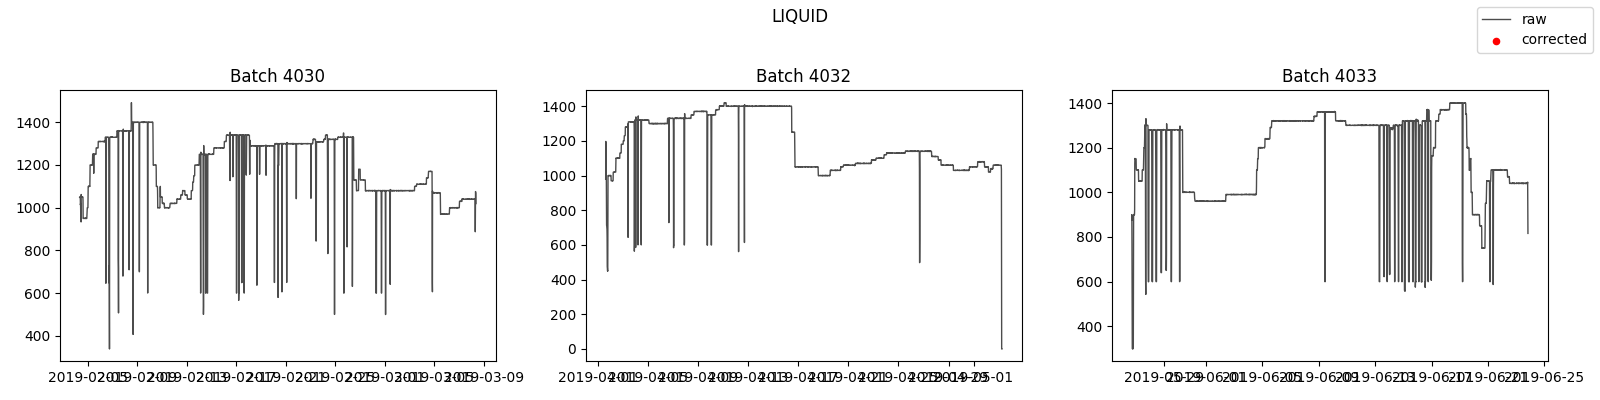

In [105]:
plot_column_batches(op_df, "LIQUID", op_df_cleaned, max_batches=3)

In [186]:
def batch_column_missing_summary(df, batch):

    cols = df.columns.drop(["Date and time", "Batch"])
    results = []

    for col in cols:

        summary = batch_timeseries_summary(df, value_col=col)

        row = summary[summary["Batch"] == batch].copy()

        row["column"] = col

        results.append(row[["Batch", "column", "rows", "missing_timestamps", "nan_values"]])

    result = pd.concat(results, ignore_index=True)

    # keep only columns with issues
    result = result[
        (result["missing_timestamps"] != 0) |
        (result["nan_values"] != 0)
    ]

    return result.sort_values("column").reset_index(drop=True)

In [187]:
batch_column_missing_summary(op_df, 4051)

,Batch,column,rows,missing_timestamps,nan_values
0,4051,GAS,9204,1,406
1,4051,GAS.1,9204,1,403
2,4051,GAS.2,9204,1,403
3,4051,GAS.3,9204,1,403
4,4051,LIQUID,9204,1,407
5,4051,LIQUID.1,9204,1,398
6,4051,LIQUID.2,9204,1,403
7,4051,LIQUID.3,9204,1,399
8,4051,LIQUID.4,9204,1,402
9,4051,LIQUID.5,9204,1,398


In [190]:
sensor_cols = op_df.columns.drop(["Date and time", "Batch"])

for col in sensor_cols:
    print(f"\n===== {col} =====")
    display(detect_time_gaps(op_df, 4051, column=col, freq='5min'))


===== LIQUID =====


,first,last,n_missing,duration,batch,gap_type
0,2021-02-20 23:00:00,2021-02-20 23:00:00,1,0 days 00:05:00,4051,missing_timestamp
1,2021-02-02 06:05:00,2021-02-03 15:10:00,398,1 days 09:10:00,4051,LIQUID_nan
2,2021-02-04 12:35:00,2021-02-04 13:15:00,9,0 days 00:45:00,4051,LIQUID_nan



===== LIQUID.1 =====


,first,last,n_missing,duration,batch,gap_type
0,2021-02-20 23:00:00,2021-02-20 23:00:00,1,0 days 00:05:00,4051,missing_timestamp
1,2021-02-02 06:25:00,2021-02-03 15:10:00,394,1 days 08:50:00,4051,LIQUID.1_nan
2,2021-02-04 13:00:00,2021-02-04 13:15:00,4,0 days 00:20:00,4051,LIQUID.1_nan



===== LIQUID.2 =====


...

,first,last,n_missing,duration,batch,gap_type
0,2021-02-20 23:00:00,2021-02-20 23:00:00,1,0 days 00:05:00,4051,missing_timestamp
1,2021-02-02 06:25:00,2021-02-03 15:10:00,394,1 days 08:50:00,4051,PRESSURE_nan
2,2021-02-04 12:55:00,2021-02-04 13:15:00,5,0 days 00:25:00,4051,PRESSURE_nan



===== PRESSURE.1 =====


,first,last,n_missing,duration,batch,gap_type
0,2021-02-20 23:00:00,2021-02-20 23:00:00,1,0 days 00:05:00,4051,missing_timestamp
1,2021-02-02 06:05:00,2021-02-03 15:10:00,398,1 days 09:10:00,4051,PRESSURE.1_nan
2,2021-02-04 12:55:00,2021-02-04 13:15:00,5,0 days 00:25:00,4051,PRESSURE.1_nan



===== OXYGEN =====


,first,last,n_missing,duration,batch,gap_type
0,2021-02-20 23:00:00,2021-02-20 23:00:00,1,0 days 00:05:00,4051,missing_timestamp
1,2021-02-02 06:05:00,2021-02-03 15:10:00,398,1 days 09:10:00,4051,OXYGEN_nan
2,2021-02-04 12:55:00,2021-02-04 13:15:00,5,0 days 00:25:00,4051,OXYGEN_nan


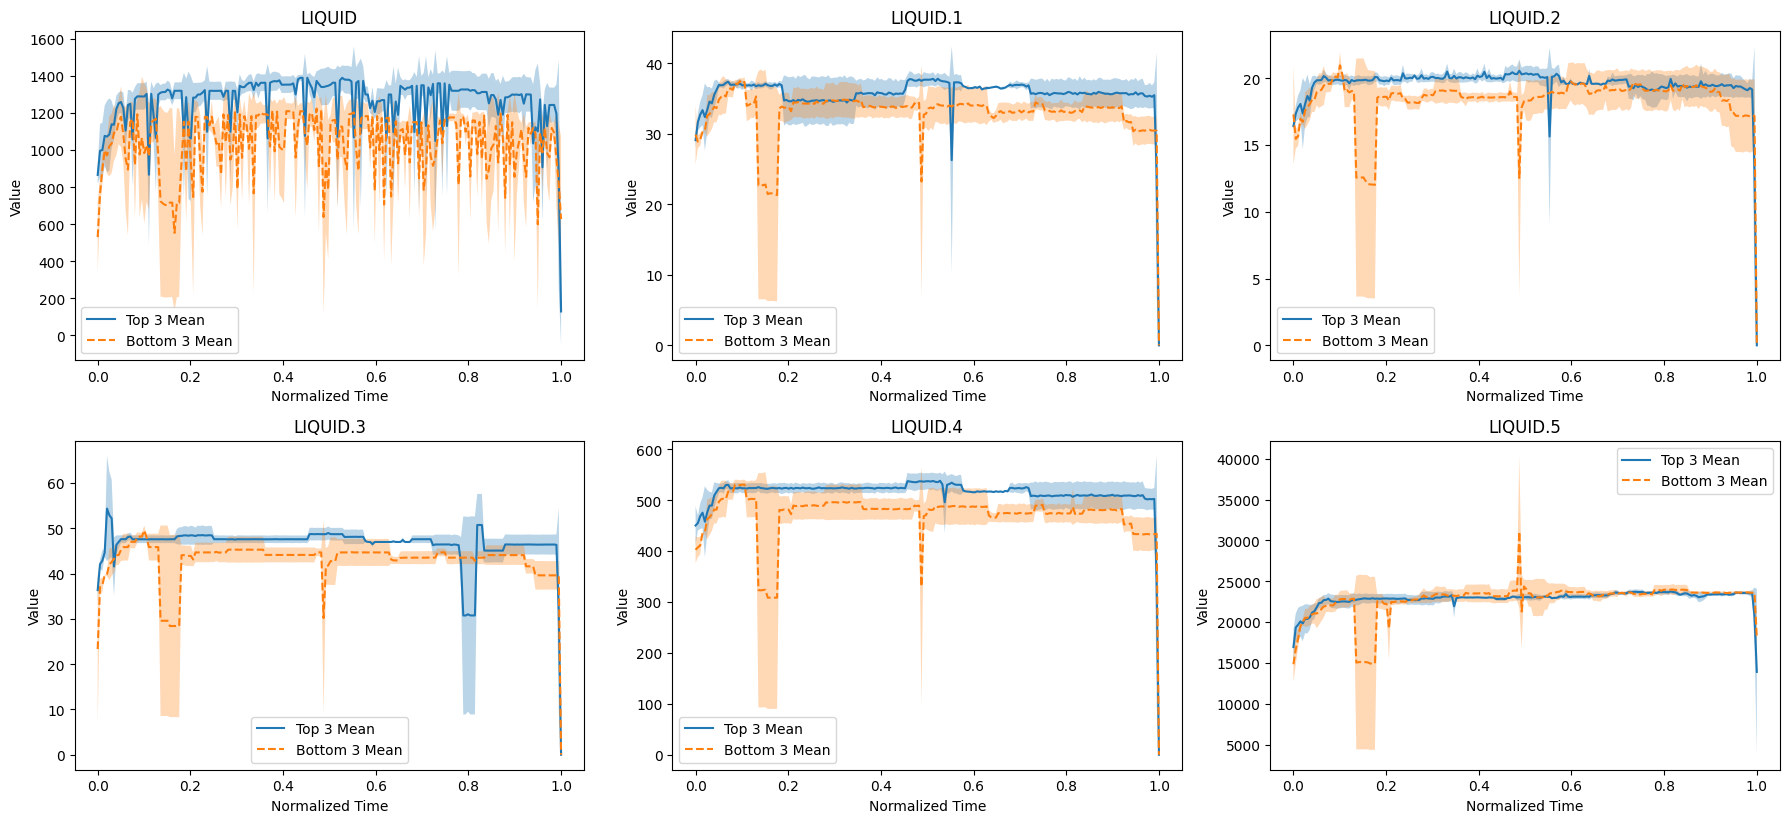

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Define fixed normalized time grid
time_grid = np.linspace(0, 1, 200)

# Get ranks
ranks = sorted(df["productivity_rank"].unique())
top3 = ranks[:3]
bottom3 = ranks[-3:]

liquid_cols = [
    "LIQUID",
    "LIQUID.1",
    "LIQUID.2",
    "LIQUID.3",
    "LIQUID.4",
    "LIQUID.5"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, liquid in enumerate(liquid_cols):
    ax = axes[idx]

    # -------------------------
    # TOP 3
    # -------------------------
    top_curves = []

    for rank in top3:
        batch_ids = df[df["productivity_rank"] == rank]["Batch"].unique()
        for batch in batch_ids:
            batch_df = df[df["Batch"] == batch]
            interp_vals = np.interp(
                time_grid,
                batch_df["norm_time"],
                batch_df[liquid]
            )
            top_curves.append(interp_vals)

    top_curves = np.array(top_curves)
    top_mean = top_curves.mean(axis=0)
    top_std = top_curves.std(axis=0)

    ax.plot(time_grid, top_mean, label="Top 3 Mean")
    ax.fill_between(
        time_grid,
        top_mean - top_std,
        top_mean + top_std,
        alpha=0.3
    )

    # -------------------------
    # BOTTOM 3
    # -------------------------
    bottom_curves = []

    for rank in bottom3:
        batch_ids = df[df["productivity_rank"] == rank]["Batch"].unique()
        for batch in batch_ids:
            batch_df = df[df["Batch"] == batch]
            interp_vals = np.interp(
                time_grid,
                batch_df["norm_time"],
                batch_df[liquid]
            )
            bottom_curves.append(interp_vals)

    bottom_curves = np.array(bottom_curves)
    bottom_mean = bottom_curves.mean(axis=0)
    bottom_std = bottom_curves.std(axis=0)

    ax.plot(time_grid, bottom_mean, linestyle="--", label="Bottom 3 Mean")
    ax.fill_between(
        time_grid,
        bottom_mean - bottom_std,
        bottom_mean + bottom_std,
        alpha=0.3
    )

    ax.set_title(liquid)
    ax.set_xlabel("Normalized Time")
    ax.set_ylabel("Value")
    ax.legend()

# Remove unused axes
for i in range(len(liquid_cols), 9):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

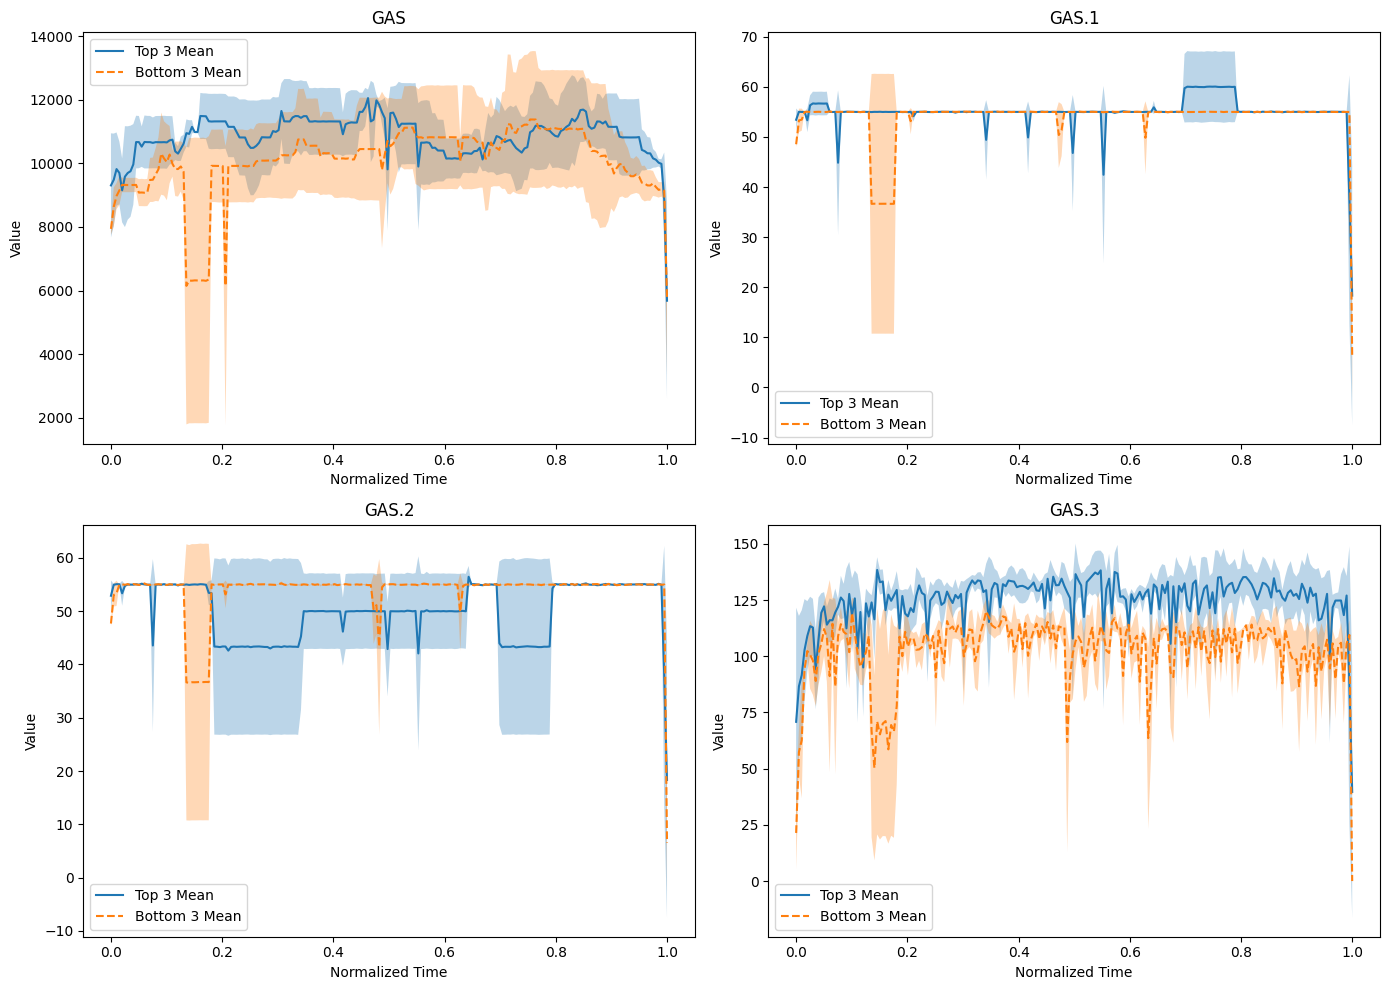

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Define fixed normalized time grid
time_grid = np.linspace(0, 1, 200)

# Get ranks
ranks = sorted(df["productivity_rank"].unique())
top3 = ranks[:3]
bottom3 = ranks[-3:]

gas_cols = [
    "GAS",
    "GAS.1",
    "GAS.2",
    "GAS.3"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, gas in enumerate(gas_cols):
    ax = axes[idx]

    # -------------------------
    # TOP 3
    # -------------------------
    top_curves = []

    for rank in top3:
        batch_ids = df[df["productivity_rank"] == rank]["Batch"].unique()
        for batch in batch_ids:
            batch_df = df[df["Batch"] == batch]
            interp_vals = np.interp(
                time_grid,
                batch_df["norm_time"],
                batch_df[gas]
            )
            top_curves.append(interp_vals)

    top_curves = np.array(top_curves)
    top_mean = top_curves.mean(axis=0)
    top_std = top_curves.std(axis=0)

    ax.plot(time_grid, top_mean, label="Top 3 Mean")
    ax.fill_between(
        time_grid,
        top_mean - top_std,
        top_mean + top_std,
        alpha=0.3
    )

    # -------------------------
    # BOTTOM 3
    # -------------------------
    bottom_curves = []

    for rank in bottom3:
        batch_ids = df[df["productivity_rank"] == rank]["Batch"].unique()
        for batch in batch_ids:
            batch_df = df[df["Batch"] == batch]
            interp_vals = np.interp(
                time_grid,
                batch_df["norm_time"],
                batch_df[gas]
            )
            bottom_curves.append(interp_vals)

    bottom_curves = np.array(bottom_curves)
    bottom_mean = bottom_curves.mean(axis=0)
    bottom_std = bottom_curves.std(axis=0)

    ax.plot(time_grid, bottom_mean, linestyle="--", label="Bottom 3 Mean")
    ax.fill_between(
        time_grid,
        bottom_mean - bottom_std,
        bottom_mean + bottom_std,
        alpha=0.3
    )

    ax.set_title(gas)
    ax.set_xlabel("Normalized Time")
    ax.set_ylabel("Value")
    ax.legend()

plt.tight_layout()
plt.show()

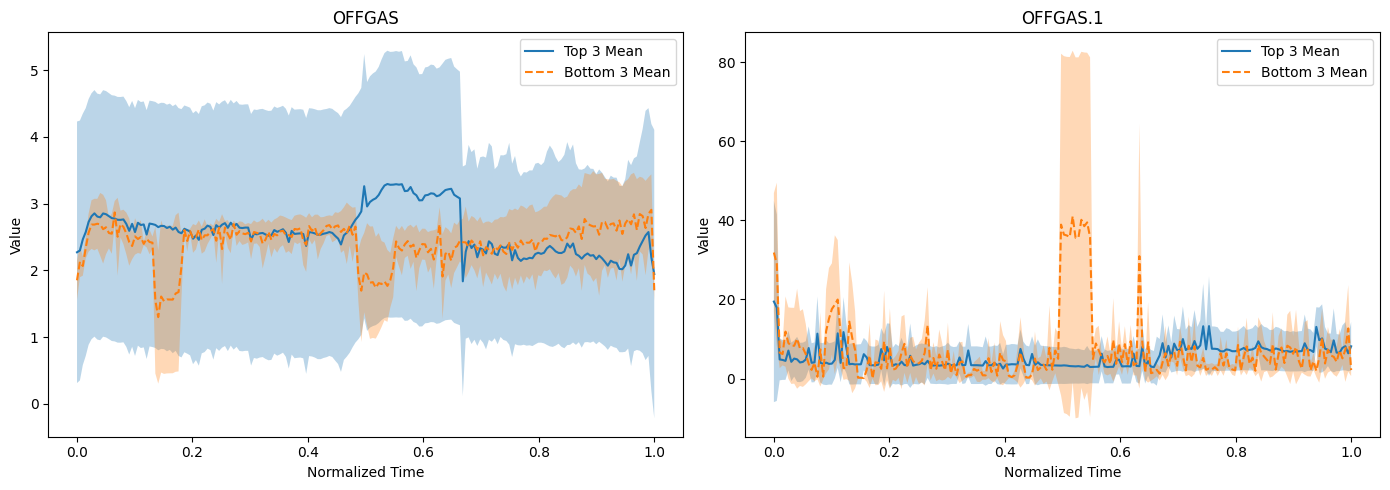

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Define fixed normalized time grid
time_grid = np.linspace(0, 1, 200)

# Get ranks
ranks = sorted(df["productivity_rank"].unique())
top3 = ranks[:3]
bottom3 = ranks[-3:]

offgas_cols = [
    "OFFGAS",
    "OFFGAS.1"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, var in enumerate(offgas_cols):
    ax = axes[idx]

    # -------------------------
    # TOP 3
    # -------------------------
    top_curves = []

    for rank in top3:
        batch_ids = df[df["productivity_rank"] == rank]["Batch"].unique()
        for batch in batch_ids:
            batch_df = df[df["Batch"] == batch]
            interp_vals = np.interp(
                time_grid,
                batch_df["norm_time"],
                batch_df[var]
            )
            top_curves.append(interp_vals)

    top_curves = np.array(top_curves)
    top_mean = np.nanmean(top_curves, axis=0)
    top_std = np.nanstd(top_curves, axis=0)

    ax.plot(time_grid, top_mean, label="Top 3 Mean")
    ax.fill_between(
        time_grid,
        top_mean - top_std,
        top_mean + top_std,
        alpha=0.3
    )

    # -------------------------
    # BOTTOM 3
    # -------------------------
    bottom_curves = []

    for rank in bottom3:
        batch_ids = df[df["productivity_rank"] == rank]["Batch"].unique()
        for batch in batch_ids:
            batch_df = df[df["Batch"] == batch]
            interp_vals = np.interp(
                time_grid,
                batch_df["norm_time"],
                batch_df[var]
            )
            bottom_curves.append(interp_vals)

    bottom_curves = np.array(bottom_curves)
    bottom_mean = np.nanmean(bottom_curves, axis=0)
    bottom_std = np.nanstd(bottom_curves, axis=0)

    ax.plot(time_grid, bottom_mean, linestyle="--", label="Bottom 3 Mean")
    ax.fill_between(
        time_grid,
        bottom_mean - bottom_std,
        bottom_mean + bottom_std,
        alpha=0.3
    )

    ax.set_title(var)
    ax.set_xlabel("Normalized Time")
    ax.set_ylabel("Value")
    ax.legend()

plt.tight_layout()
plt.show()

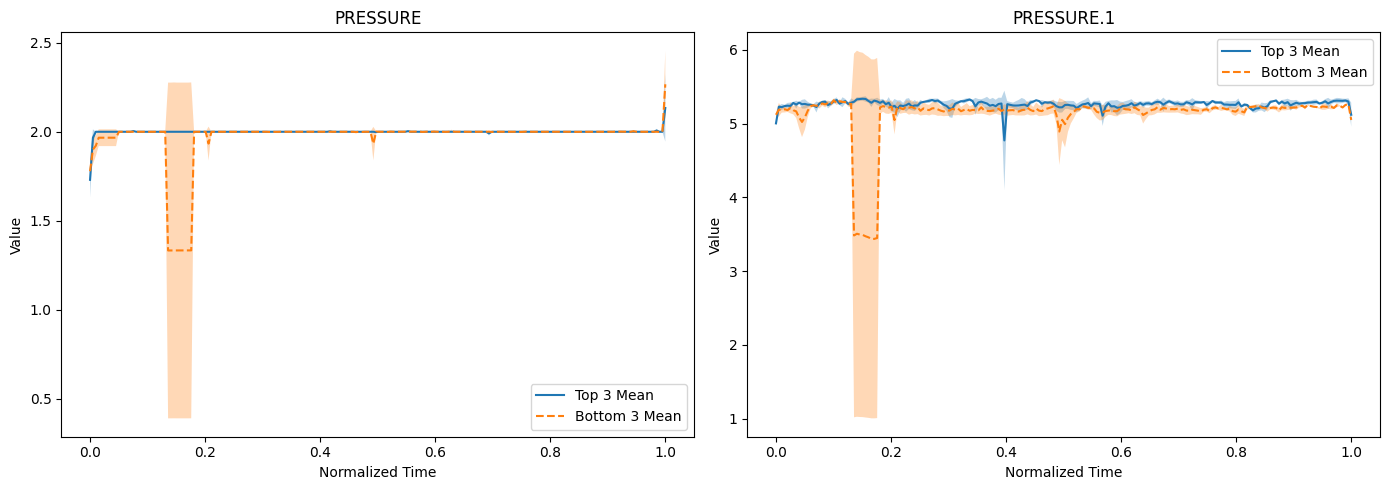

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Define fixed normalized time grid
time_grid = np.linspace(0, 1, 200)

# Get ranks
ranks = sorted(df["productivity_rank"].unique())
top3 = ranks[:3]
bottom3 = ranks[-3:]

pressure_cols = [
    "PRESSURE",
    "PRESSURE.1"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, var in enumerate(pressure_cols):
    ax = axes[idx]

    # -------------------------
    # TOP 3
    # -------------------------
    top_curves = []

    for rank in top3:
        batch_ids = df[df["productivity_rank"] == rank]["Batch"].unique()
        for batch in batch_ids:
            batch_df = df[df["Batch"] == batch]
            interp_vals = np.interp(
                time_grid,
                batch_df["norm_time"],
                batch_df[var]
            )
            top_curves.append(interp_vals)

    top_curves = np.array(top_curves)
    top_mean = np.nanmean(top_curves, axis=0)
    top_std = np.nanstd(top_curves, axis=0)

    ax.plot(time_grid, top_mean, label="Top 3 Mean")
    ax.fill_between(
        time_grid,
        top_mean - top_std,
        top_mean + top_std,
        alpha=0.3
    )

    # -------------------------
    # BOTTOM 3
    # -------------------------
    bottom_curves = []

    for rank in bottom3:
        batch_ids = df[df["productivity_rank"] == rank]["Batch"].unique()
        for batch in batch_ids:
            batch_df = df[df["Batch"] == batch]
            interp_vals = np.interp(
                time_grid,
                batch_df["norm_time"],
                batch_df[var]
            )
            bottom_curves.append(interp_vals)

    bottom_curves = np.array(bottom_curves)
    bottom_mean = np.nanmean(bottom_curves, axis=0)
    bottom_std = np.nanstd(bottom_curves, axis=0)

    ax.plot(time_grid, bottom_mean, linestyle="--", label="Bottom 3 Mean")
    ax.fill_between(
        time_grid,
        bottom_mean - bottom_std,
        bottom_mean + bottom_std,
        alpha=0.3
    )

    ax.set_title(var)
    ax.set_xlabel("Normalized Time")
    ax.set_ylabel("Value")
    ax.legend()

plt.tight_layout()
plt.show()

In [55]:
cols_to_agg = [c for c in op_df_new.columns 
               if c not in ["Date and time"]]

df_features = op_df_new.groupby("Batch").agg({
    col: ["mean", "std", "max"] 
    for col in cols_to_agg 
    if col != "Batch"
})

# Flatten column names
df_features.columns = [
    f"{col[0]}_{col[1]}" for col in df_features.columns
]

# Bring Batch back as column
df_features = df_features.reset_index()

df_final = df_features.merge(rate_df, on="Batch", how="inner")

In [56]:
df_final

,Batch,productivity_rank_mean,productivity_rank_std,productivity_rank_max,LIQUID_mean,LIQUID_std,LIQUID_max,LIQUID.1_mean,LIQUID.1_std,LIQUID.1_max,...,PRESSURE_mean,PRESSURE_std,PRESSURE_max,PRESSURE.1_mean,PRESSURE.1_std,PRESSURE.1_max,OXYGEN_mean,OXYGEN_std,OXYGEN_max,product_rate
0,4030,12.0,0.0,12,1182.105195,147.147279,1432.697500,34.691378,3.450833,37.837500,...,1.986456,0.050147,2.015000,5.274639,0.093954,5.375000,20.267168,19.042293,92.507500,616.305179
1,4032,11.0,0.0,11,1183.950284,161.383664,1420.087500,32.574369,3.906445,36.872500,...,1.912303,0.099427,2.070000,5.156506,0.133840,5.360000,22.233264,18.594257,100.542500,621.162886
2,4033,14.0,0.0,14,1163.780473,187.711904,1400.392500,34.187449,4.287938,37.667500,...,1.966133,0.073306,2.005000,5.178177,0.131001,5.360000,22.588357,18.323368,72.872500,608.869223
3,4034,9.0,0.0,9,1179.522407,138.158795,1325.395000,35.252449,2.455331,36.670000,...,1.992551,0.037362,2.002500,5.245424,0.081851,5.370000,14.902031,13.366028,76.975000,622.196071
4,4035,15.0,0.0,15,1169.796966,93.013193,1250.270000,34.879550,3.459786,36.737500,...,1.994950,0.031267,2.000000,5.194992,0.058907,5.350000,17.178836,17.015847,59.670000,606.416985
5,4036,13.0,0.0,13,1152.169171,108.464855,1400.665000,34.109794,2.011785,36.835000,...,1.999455,0.010159,2.000000,5.237923,0.074728,5.360000,25.454919,22.598227,85.790000,609.172327
6,4037,19.0,0.0,19,1096.767667,102.726644,1344.947500,32.274569,2.455116,36.820000,...,1.997472,0.021738,2.002500,5.129160,0.113472,5.340000,24.384569,24.599791,88.252500,568.419365
7,4038,17.0,0.0,17,1130.042023,86.339043,1202.585000,32.873921,2.221794,35.090000,...,1.999951,0.018264,2.390000,5.221937,0.065535,5.347500,26.365073,17.456859,100.742500,593.373544
8,4039,18.0,0.0,18,1120.305728,93.607176,1229.442500,32.592180,2.330617,33.315000,...,1.972337,0.144817,2.000000,5.161669,0.354232,5.367500,0.000000,0.000000,0.000000,581.763278
9,4040,4.0,0.0,4,1251.406627,156.176315,1420.507500,35.697031,3.355910,37.842500,...,1.995909,0.036011,2.400000,5.235634,0.107692,5.370000,24.647114,19.531829,103.415000,651.303020


In [57]:
corr = df_final.corr(numeric_only=True)["product_rate"].sort_values(ascending=False)

print(corr)

product_rate              1.000000
LIQUID_mean               0.838811
GAS.3_mean                0.790065
GAS.3_max                 0.645994
LIQUID.4_mean             0.597881
LIQUID.1_mean             0.551542
PRESSURE.1_max            0.501696
LIQUID.2_max              0.422078
LIQUID.2_mean             0.395018
OFFGAS_std                0.389067
LIQUID.4_max              0.308482
LIQUID.1_max              0.300312
LIQUID.3_max              0.260974
GAS_mean                  0.250527
OXYGEN_std                0.235134
OXYGEN_max                0.230809
GAS.2_std                 0.183093
GAS.3_std                 0.177932
pH_max                    0.168021
LIQUID.3_std              0.159186
GAS_max                   0.142701
LIQUID.3_mean             0.114101
OFFGAS_max                0.110077
OFFGAS.1_mean             0.099244
GAS.1_max                 0.094503
GAS.1_std                 0.092319
LIQUID.1_std              0.088597
pH_mean                   0.084012
LIQUID.4_std        

In [58]:
df = df_final[['LIQUID_mean', 'GAS.3_mean', 'product_rate', 'LIQUID.4_mean']]

In [35]:
df

,LIQUID_mean,GAS.3_mean,product_rate,LIQUID.4_mean
0,1182.324976,109.610918,616.305179,496.263217
1,1184.364106,118.538008,621.162886,463.319444
2,1164.284559,116.023111,608.869223,486.013781
3,1179.522407,117.980254,622.196071,499.846881
4,1171.137963,114.965166,606.416985,494.881918
5,1152.217926,114.503684,609.172327,485.617397
6,1096.785202,106.092645,568.419365,462.000701
7,1130.309940,112.022737,593.373544,469.156314
8,1115.926942,103.492743,581.763278,458.862198
9,1251.895245,120.983147,651.303020,509.931691


In [59]:
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = df[["LIQUID_mean", "GAS.3_mean", 'LIQUID.4_mean' ]]
y = df["product_rate"]

loo = LeaveOneOut()

def loocv_r2(model, X, y):
    preds = np.zeros(len(y))
    
    for train_idx, test_idx in loo.split(X):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds[test_idx] = model.predict(X.iloc[test_idx])
    
    return r2_score(y, preds)

model1 = LinearRegression()
r2_linear = loocv_r2(model1, X, y)
print("Linear Regression LOOCV R²:", r2_linear)

model2 = make_pipeline(StandardScaler(), Ridge(alpha=5.0))
r2_ridge = loocv_r2(model2, X, y)
print("Ridge Regression LOOCV R²:", r2_ridge)

model3 = RandomForestRegressor(
    n_estimators=100,
    max_depth=2,
    random_state=42
)

r2_rf = loocv_r2(model3, X, y)
print("Random Forest LOOCV R²:", r2_rf)

Linear Regression LOOCV R²: 0.5790690680152304
Ridge Regression LOOCV R²: 0.5861522276899669
Random Forest LOOCV R²: 0.46290114311301966


In [66]:
def loocv_r2_loglog(model, X, y):
    preds = np.zeros(len(y))
    
    for train_idx, test_idx in loo.split(X):
        X_train_log = np.log(X.iloc[train_idx])
        X_test_log = np.log(X.iloc[test_idx])
        y_train_log = np.log(y.iloc[train_idx])
        
        model.fit(X_train_log, y_train_log)
        pred_log = model.predict(X_test_log)
        preds[test_idx] = np.exp(pred_log)
    
    return r2_score(y, preds)

model_loglog = LinearRegression()
r2_loglog = loocv_r2_loglog(model_loglog, X, y)

print("Log-Log LOOCV R²:", r2_loglog)

Log-Log LOOCV R²: 0.8409438570960488


In [45]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

# -------------------------
# Feature Extraction
# -------------------------

def extract_phase_features(df, n_points=200):

    feature_rows = []

    for batch_id, batch_df in df.groupby("Batch"):

        batch_df = batch_df.sort_values("Date and time")

        # Normalized time
        t = np.linspace(0.0, 1.0, len(batch_df))

        oxygen = batch_df["OXYGEN"].astype(float).values
        gas = batch_df["TOTAL_GAS_INFLOW"].astype(float).values
        liquid = batch_df["TOTAL_LIQUID_INFLOW"].astype(float).values

        # Early phase mask (0–0.2)
        early_mask = t <= 0.2

        # ----- EARLY GAS FEATURES -----
        early_gas_mean = gas[early_mask].mean()
        early_gas_integral = np.trapezoid(gas[early_mask], t[early_mask])
        early_gas_slope = linregress(t[early_mask], gas[early_mask]).slope

        # ----- EARLY OXYGEN FEATURES -----
        early_oxy_mean = oxygen[early_mask].mean()
        early_oxy_integral = np.trapezoid(oxygen[early_mask], t[early_mask])
        early_oxy_slope = linregress(t[early_mask], oxygen[early_mask]).slope
        early_oxy_drop = oxygen[0] - oxygen[early_mask].min()

        # Optional liquid
        early_liq_mean = liquid[early_mask].mean()

        feature_rows.append({
            "Batch": batch_id,
            "early_gas_mean": early_gas_mean,
            "early_gas_integral": early_gas_integral,
            "early_gas_slope": early_gas_slope,
            "early_oxy_mean": early_oxy_mean,
            "early_oxy_integral": early_oxy_integral,
            "early_oxy_slope": early_oxy_slope,
            "early_oxy_drop": early_oxy_drop,
            "early_liq_mean": early_liq_mean,
        })

    return pd.DataFrame(feature_rows)


features_df = extract_phase_features(op_df_new)

In [46]:
features_df

,Batch,early_gas_mean,early_gas_integral,early_gas_slope,early_oxy_mean,early_oxy_integral,early_oxy_slope,early_oxy_drop,early_liq_mean
0,4030,112.746767,21.621801,132.409028,20.588332,3.386805,-24.691626,21.190509,24497.491038
1,4032,10359.909127,1950.763598,14699.654890,26.017883,4.704921,-289.760394,45.043205,23448.410896
2,4033,9413.862085,1696.064757,-1498.549713,26.682353,4.153993,-36.744981,46.265058,23251.612905
3,4034,8541.456845,1612.311678,-13941.489167,20.785729,3.576219,110.246786,23.787604,24108.842819
4,4035,9197.285802,1705.338650,763.250384,11.149941,2.032814,-42.301687,8.124646,22489.498149
5,4036,9912.929956,1863.234702,4387.533794,28.261168,4.864534,110.136365,24.560574,24169.379717
6,4037,8956.236254,1637.135637,595.362533,42.116375,7.375339,-9.684583,31.949687,22303.141254
7,4038,9324.434691,1611.931563,-3115.555521,36.260048,6.128730,85.587657,11.219139,23798.185734
8,4039,9111.701431,1519.392083,-1172.652529,0.000000,0.000000,0.000000,0.000000,23230.272886
9,4040,9632.780603,1669.066734,7463.179880,21.520925,3.396313,73.082727,7.785238,23643.312757


In [47]:
rate_df

,Batch,product_rate
0,4030,616.305179
1,4032,621.162886
2,4033,608.869223
3,4034,622.196071
4,4035,606.416985
5,4036,609.172327
6,4037,568.419365
7,4038,593.373544
8,4039,581.763278
9,4040,651.303020


In [49]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# -------------------------
# Merge
# -------------------------
df = features_df.merge(rate_df, on="Batch", how="inner")

feature_cols = [c for c in df.columns if c not in ["Batch", "product_rate"]]

# Detect oxygen-missing batches (all oxy-derived features == 0)
oxy_cols = [c for c in feature_cols if "oxy" in c.lower()]
all_oxy_zero = (df[oxy_cols].abs().sum(axis=1) == 0)

print("Batches with all oxygen features == 0:", df.loc[all_oxy_zero, "Batch"].tolist())

# Drop them (for oxygen-dynamics analysis)
df_model = df.loc[~all_oxy_zero].copy()

X = df_model[feature_cols].astype(float)          # <-- DataFrame (keeps feature names)
y = df_model["product_rate"].astype(float)        # <-- Series

loo = LeaveOneOut()

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 200)))
])

lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(cv=5, max_iter=20000, random_state=0))
])

def loocv_predictions_df(estimator, X_df, y_ser):
    preds = np.zeros(len(y_ser), dtype=float)
    for train_idx, test_idx in loo.split(X_df):
        X_train, X_test = X_df.iloc[train_idx], X_df.iloc[test_idx]
        y_train = y_ser.iloc[train_idx]
        estimator.fit(X_train, y_train)
        preds[test_idx] = estimator.predict(X_test)
    return preds

ridge_preds = loocv_predictions_df(ridge, X, y)
lasso_preds = loocv_predictions_df(lasso, X, y)

print("\n--- LOBO CV Performance ---")
print(f"Ridge  R2: {r2_score(y, ridge_preds):.3f} | MAE: {mean_absolute_error(y, ridge_preds):.3f}")
print(f"Lasso  R2: {r2_score(y, lasso_preds):.3f} | MAE: {mean_absolute_error(y, lasso_preds):.3f}")

# Fit full for interpretation
ridge.fit(X, y)
lasso.fit(X, y)

coef_table = pd.DataFrame({
    "feature": feature_cols,
    "ridge_coef": ridge.named_steps["model"].coef_,
    "lasso_coef": lasso.named_steps["model"].coef_,
}).sort_values("ridge_coef", key=lambda s: np.abs(s), ascending=False)

print("\n--- Coefficients (sorted by |ridge_coef|) ---")
print(coef_table.to_string(index=False))

print("\n--- Lasso selected features (non-zero) ---")
print(coef_table.loc[coef_table["lasso_coef"].abs() > 1e-8, ["feature", "lasso_coef"]].to_string(index=False))

# Permutation importance (no warnings now)
perm = permutation_importance(
    ridge, X, y,
    scoring="r2", n_repeats=200, random_state=0
)

perm_table = pd.DataFrame({
    "feature": feature_cols,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance_mean", ascending=False)

print("\n--- Permutation importance (R2 drop) ---")
print(perm_table.to_string(index=False))

Batches with all oxygen features == 0: [4039]

--- LOBO CV Performance ---
Ridge  R2: 0.088 | MAE: 27.607
Lasso  R2: 0.093 | MAE: 26.949

--- Coefficients (sorted by |ridge_coef|) ---
           feature  ridge_coef  lasso_coef
   early_gas_slope   18.333204   19.790977
    early_oxy_drop   15.182896   24.513397
early_gas_integral  -12.449917  -37.658281
    early_gas_mean   10.977919   36.016739
    early_liq_mean    9.210701   12.345771
early_oxy_integral   -8.704538  -11.700520
   early_oxy_slope   -3.454687    3.149609
    early_oxy_mean    3.123493    0.000000

--- Lasso selected features (non-zero) ---
           feature  lasso_coef
   early_gas_slope   19.790977
    early_oxy_drop   24.513397
early_gas_integral  -37.658281
    early_gas_mean   36.016739
    early_liq_mean   12.345771
early_oxy_integral  -11.700520
   early_oxy_slope    3.149609

--- Permutation importance (R2 drop) ---
           feature  perm_importance_mean  perm_importance_std
   early_gas_slope              0

In [50]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# -------------------------
# Merge
# -------------------------
df = features_df.merge(rate_df, on="Batch", how="inner")

# Detect oxygen-missing batches (all oxy-derived features == 0)
all_feature_cols = [c for c in df.columns if c not in ["Batch", "product_rate"]]
oxy_cols = [c for c in all_feature_cols if "oxy" in c.lower()]
all_oxy_zero = (df[oxy_cols].abs().sum(axis=1) == 0)

print("Batches with all oxygen features == 0:", df.loc[all_oxy_zero, "Batch"].tolist())

# Drop them (for oxygen-dynamics analysis)
df_model = df.loc[~all_oxy_zero].copy()

# -------------------------
# Pick "strong" features
# (edit this list if you want)
# -------------------------
strong_features = [
    "early_gas_slope",
    "early_oxy_drop",
    "early_gas_integral",
    "early_gas_mean",
    "early_liq_mean",
    "early_oxy_integral",
]

# Keep only features that actually exist in df_model
strong_features = [c for c in strong_features if c in df_model.columns]
if len(strong_features) == 0:
    raise ValueError("None of the strong_features are present in df_model columns.")

X = df_model[strong_features].astype(float)
y = df_model["product_rate"].astype(float)

loo = LeaveOneOut()

# -------------------------
# LOOCV helper
# -------------------------
def loocv_predictions(estimator, X_df, y_ser):
    preds = np.zeros(len(y_ser), dtype=float)
    for train_idx, test_idx in loo.split(X_df):
        X_train, X_test = X_df.iloc[train_idx], X_df.iloc[test_idx]
        y_train = y_ser.iloc[train_idx]
        estimator.fit(X_train, y_train)
        preds[test_idx] = estimator.predict(X_test)
    return preds

def evaluate_model(name, est, X, y):
    preds = loocv_predictions(est, X, y)
    r2 = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    print(f"{name:<20} R2: {r2:>6.3f} | MAE: {mae:>7.3f}")
    return preds, r2, mae

# -------------------------
# Models
# -------------------------
models = {}

# Ridge (linear)
models["RidgeCV"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 200)))
])

# Lasso (linear sparse)
models["LassoCV"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(cv=5, max_iter=50000, random_state=0))
])

# PLS Regression (linear, good for correlated sensors)
# NOTE: choose n_components carefully (<= n_features)
max_comp = min(len(strong_features), 6)
models["PLS(1)"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", PLSRegression(n_components=1))
])
if max_comp >= 2:
    models["PLS(2)"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=2))
    ])
if max_comp >= 3:
    models["PLS(3)"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=3))
    ])

# Random Forest (nonlinear)
models["RandomForest"] = RandomForestRegressor(
    n_estimators=2000,
    random_state=0,
    min_samples_leaf=2,
    max_features="sqrt"
)

# Gradient Boosting (nonlinear, often strong on tabular)
models["GradBoost"] = GradientBoostingRegressor(
    random_state=0,
    n_estimators=800,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.9
)

# -------------------------
# Evaluate
# -------------------------
print("\n--- LOOCV performance using strong features ---")
results = []
pred_store = {}

for name, est in models.items():
    preds, r2, mae = evaluate_model(name, est, X, y)
    results.append((name, r2, mae))
    pred_store[name] = preds

results_df = pd.DataFrame(results, columns=["model", "loocv_r2", "loocv_mae"]).sort_values("loocv_r2", ascending=False)
print("\n--- Summary ---")
print(results_df.to_string(index=False))

best_name = results_df.iloc[0]["model"]
best_est = models[best_name]

print(f"\nBest by LOOCV R2: {best_name}")

# -------------------------
# Fit best model on full data + feature importance
# -------------------------
best_est.fit(X, y)

print("\n--- Feature importance / interpretation (best model) ---")

# Linear model coefficients
if isinstance(best_est, Pipeline) and hasattr(best_est.named_steps.get("model", None), "coef_"):
    model = best_est.named_steps["model"]
    # coef_ shape depends on model
    coef = model.coef_.ravel() if hasattr(model.coef_, "ravel") else np.array(model.coef_)
    coef_df = pd.DataFrame({"feature": strong_features, "coef": coef})
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)
    print("\nCoefficients (sorted by |coef|):")
    print(coef_df[["feature", "coef"]].to_string(index=False))

# RF / GB feature_importances_
elif hasattr(best_est, "feature_importances_"):
    imp = best_est.feature_importances_
    imp_df = pd.DataFrame({"feature": strong_features, "importance": imp}).sort_values("importance", ascending=False)
    print("\nTree importance (Gini gain proxy):")
    print(imp_df.to_string(index=False))

# Always do permutation importance for comparability
print("\nPermutation importance on best model (R2 drop):")
perm = permutation_importance(best_est, X, y, scoring="r2", n_repeats=500, random_state=0)
perm_df = pd.DataFrame({
    "feature": strong_features,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance_mean", ascending=False)
print(perm_df.to_string(index=False))

# -------------------------
# Optional: show predictions vs actual for best model
# -------------------------
best_preds = pred_store[best_name]
pred_df = pd.DataFrame({
    "Batch": df_model["Batch"].values,
    "y_true": y.values,
    "y_pred_loocv": best_preds
}).sort_values("y_true", ascending=False)

print("\n--- LOOCV predictions (best model) ---")
print(pred_df.to_string(index=False))

Batches with all oxygen features == 0: [4039]

--- LOOCV performance using strong features ---
RidgeCV              R2:  0.275 | MAE:  24.254
LassoCV              R2:  0.107 | MAE:  25.740
PLS(1)               R2: -0.070 | MAE:  30.497
PLS(2)               R2:  0.079 | MAE:  28.706
PLS(3)               R2: -0.070 | MAE:  30.304
RandomForest         R2:  0.064 | MAE:  29.238
GradBoost            R2: -0.156 | MAE:  31.732

--- Summary ---
       model  loocv_r2  loocv_mae
     RidgeCV  0.274654  24.253606
     LassoCV  0.106854  25.740254
      PLS(2)  0.079018  28.705650
RandomForest  0.064102  29.237988
      PLS(1) -0.069806  30.497134
      PLS(3) -0.069889  30.303677
   GradBoost -0.155595  31.731902

Best by LOOCV R2: RidgeCV

--- Feature importance / interpretation (best model) ---

Coefficients (sorted by |coef|):
           feature       coef
early_gas_integral -22.411763
    early_gas_mean  20.880030
    early_oxy_drop  19.943466
   early_gas_slope  19.234364
    early_liq_mean

In [14]:
def pressure_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    p = early["MEAN_PRESSURE"].values

    return {
        "pressure_mean_early": np.mean(p),
        "pressure_min_early": np.min(p),
        "pressure_std_early": np.std(p),
        "pressure_drop_duration": np.sum(p < 3.2),  # threshold based on plot
        "pressure_drop_flag": int(np.min(p) < 3.0)
    }

def gas_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    g = early["TOTAL_GAS_INFLOW"].values
    t = np.arange(len(g))

    return {
        "gas_mean_early": np.mean(g),
        "gas_slope_early": np.polyfit(t, g, 1)[0],
        "gas_min_early": np.min(g),
        "gas_drop_flag": int(np.min(g) < 8000)
    }


def offgas_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    o = early["MEAN_OFFGAS"].values

    return {
        "offgas_mean_early": np.mean(o),
        "offgas_std_early": np.std(o),
        "offgas_peak_early": np.max(o)
    }


def ph_features(df, batch_id):
    batch = df[df["Batch"] == batch_id].copy()
    batch = batch.sort_values("Date and time")
    batch["time_norm"] = np.linspace(0, 1, len(batch))
    early = batch[batch["time_norm"] <= 0.5]

    p = early["pH"].values

    return {
        "pH_min_early": np.min(p),
        "pH_drop_flag": int(np.min(p) < 5.0)
    }

In [16]:
import pandas as pd

all_features = []

for batch in op_df_new["Batch"].unique():
    f = {}
    f.update(pressure_features(op_df_new, batch))
    f.update(gas_features(op_df_new, batch))
    f.update(offgas_features(op_df_new, batch))
    f.update(ph_features(op_df_new, batch))
    f["Batch"] = batch
    all_features.append(f)

features_df = pd.DataFrame(all_features)

In [18]:
features_df

,pressure_mean_early,pressure_min_early,pressure_std_early,pressure_drop_duration,pressure_drop_flag,gas_mean_early,gas_slope_early,gas_min_early,gas_drop_flag,offgas_mean_early,offgas_std_early,offgas_peak_early,pH_min_early,pH_drop_flag,Batch
0,3.631059,0.0000,0.201492,3,1,10872.326943,4.342951,0.000000,1,7.001889,2.738776,33.732500,0.000000,1,4041
1,3.644207,3.4000,0.029227,0,0,11857.349042,6.128647,5380.905000,1,0.499818,1.158605,10.837500,5.375000,0,4043
2,3.616093,3.4000,0.033777,0,0,10788.798325,-1.726155,6076.530000,1,3.121452,1.518057,16.402500,5.565000,0,4047
3,3.619550,3.1150,0.068220,4,0,10621.260806,3.972423,7877.800000,1,6.796807,1.544607,13.630000,3.205000,1,4040
4,2.671357,0.0000,1.594900,227,1,8032.967830,15.471019,0.000000,1,4.235148,2.834284,16.762500,0.000000,1,4042
5,3.625958,3.3950,0.029078,0,0,10428.068872,1.198697,8604.910000,0,7.162875,2.267102,19.822500,4.945000,1,4046
6,3.639962,3.3650,0.034995,0,0,11215.345437,7.854475,8576.850000,0,3.941935,3.830129,22.897500,6.510000,0,4045
7,3.588696,3.3500,0.080291,0,0,11348.538644,2.978685,7626.454000,1,1.950443,1.345192,15.311667,5.530000,0,4052
8,3.595892,3.3075,0.059205,0,0,9026.399807,2.242287,4596.130000,1,4.486441,1.175368,22.345000,5.530000,0,4034
9,3.644811,3.3650,0.041093,0,0,9758.117779,2.036422,8651.320000,0,2.505967,4.662484,43.175000,5.635000,0,4044


In [19]:
rate_df

,Batch,product_rate
0,4030,616.305179
1,4032,621.162886
2,4033,608.869223
3,4034,622.196071
4,4035,606.416985
5,4036,609.172327
6,4037,568.419365
7,4038,593.373544
8,4039,581.763278
9,4040,651.303020


In [21]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# -----------------------------
# Merge
# -----------------------------
df = features_df.merge(rate_df, on="Batch", how="inner").copy()

X = df.drop(columns=["Batch", "product_rate"])
y = df["product_rate"]

# Clean
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# -----------------------------
# Compute Pearson for each feature
# -----------------------------
results = []

for col in X.columns:
    r, p = pearsonr(X[col], y)
    
    results.append({
        "feature": col,
        "pearson_r": r,
        "p_value": p,
        "abs_r": abs(r)
    })

corr_df = pd.DataFrame(results).sort_values("abs_r", ascending=False)

print(corr_df)

                   feature  pearson_r   p_value     abs_r
10        offgas_std_early  -0.491847  0.023532  0.491847
11       offgas_peak_early  -0.458771  0.036453  0.458771
5           gas_mean_early   0.270217  0.236151  0.270217
6          gas_slope_early   0.196799  0.392534  0.196799
8            gas_drop_flag  -0.171553  0.457147  0.171553
9        offgas_mean_early   0.110651  0.633015  0.110651
13            pH_drop_flag   0.096874  0.676142  0.096874
2       pressure_std_early  -0.091391  0.693589  0.091391
7            gas_min_early   0.083580  0.718707  0.083580
1       pressure_min_early   0.069186  0.765707  0.069186
4       pressure_drop_flag  -0.062565  0.787610  0.062565
3   pressure_drop_duration   0.057008  0.806111  0.057008
12            pH_min_early   0.042949  0.853346  0.042949
0      pressure_mean_early   0.028154  0.903580  0.028154


In [22]:
X = df[["offgas_std_early", "offgas_peak_early"]]
y = df["product_rate"]

LOO RMSE: 36.98001096890533
LOO R2: -0.059728724054664895


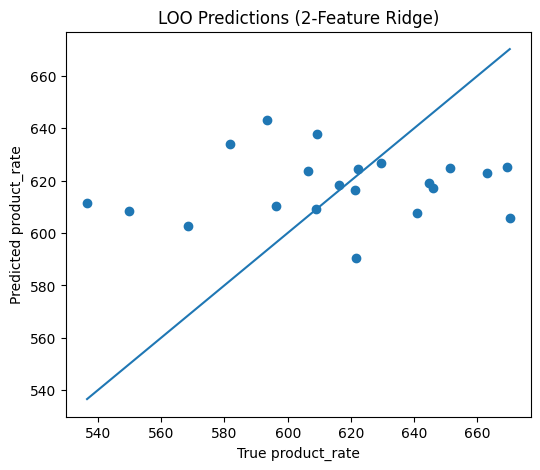


Coefficients:
             feature      coef
0   offgas_std_early -7.327797
1  offgas_peak_early -6.008644

Chosen alpha: 15.343684089300131


In [23]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# 1) X and y
# -----------------------------
X = df[["offgas_std_early", "offgas_peak_early"]].copy()
y = df["product_rate"].values

# -----------------------------
# 2) Model
# -----------------------------
alphas = np.logspace(-4, 4, 200)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas))
])

# -----------------------------
# 3) Leave-One-Out
# -----------------------------
loo = LeaveOneOut()
y_pred = cross_val_predict(model, X, y, cv=loo)

rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("LOO RMSE:", rmse)
print("LOO R2:", r2)

# -----------------------------
# 4) Plot
# -----------------------------
plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("True product_rate")
plt.ylabel("Predicted product_rate")
plt.title("LOO Predictions (2-Feature Ridge)")
plt.show()

# -----------------------------
# 5) Fit on full data for interpretation
# -----------------------------
model.fit(X, y)

ridge = model.named_steps["ridge"]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": ridge.coef_
}).sort_values("coef")

print("\nCoefficients:")
print(coef_df)

print("\nChosen alpha:", ridge.alpha_)

In [4]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_variable(df, batch_id, variable, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df[f"{variable}_smooth"] = (
        batch_df[variable]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    interp_values = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df[f"{variable}_smooth"]
    )

    return common_time, interp_values


# -------------------------
# Collect TOTAL_LIQUID_INFLOW Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_LIQUID_INFLOW")
    top_curves.append(vals)

for batch in bottom_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_LIQUID_INFLOW")
    bottom_curves.append(vals)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)


# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)


# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early TOTAL_LIQUID_INFLOW Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="TOTAL_LIQUID_INFLOW")

        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="TOTAL_LIQUID_INFLOW Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


KeyboardInterrupt: 

In [7]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_variable(df, batch_id, variable, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df[f"{variable}_smooth"] = (
        batch_df[variable]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    interp_values = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df[f"{variable}_smooth"]
    )

    return common_time, interp_values


# -------------------------
# Collect TOTAL_GAS_INFLOW Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_GAS_INFLOW")
    top_curves.append(vals)

for batch in bottom_batches:
    _, vals = get_normalized_variable(op_df_new, batch, "TOTAL_GAS_INFLOW")
    bottom_curves.append(vals)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)


# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)


# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early TOTAL_GAS_INFLOW Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="TOTAL_GAS_INFLOW")

        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="TOTAL_GAS_INFLOW Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


KeyboardInterrupt: 

In [15]:
def early_gas_features(df, batch_id):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")
    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    early = batch_df[batch_df["time_norm"] <= 0.5]

    gas = early["TOTAL_GAS_INFLOW"].values
    t = np.arange(len(gas))

    return {
        "Batch": batch_id,
        "gas_mean_early": np.mean(gas),
        "gas_std_early": np.std(gas),
        "gas_slope_early": np.polyfit(t, gas, 1)[0],
        "gas_auc_early": np.trapezoid(gas)
    }


import pandas as pd

# ---------------------------------------
# Compute early gas features for all batches
# ---------------------------------------
gas_feature_list = []

for batch_id in op_df_new["Batch"].unique():
    gas_feature_list.append(
        early_gas_features(op_df_new, batch_id)
    )

gas_features_df = pd.DataFrame(gas_feature_list)

# ---------------------------------------
# Align with productivity
# ---------------------------------------
prod_df = rate_df[["Batch", "product_rate"]]

gas_merged = gas_features_df.merge(prod_df, on="Batch")

from scipy.stats import spearmanr

results = []

for col in [
    "gas_mean_early",
    "gas_std_early",
    "gas_slope_early",
    "gas_auc_early"
]:
    corr, pval = spearmanr(
        gas_merged[col],
        gas_merged["product_rate"]
    )

    results.append({
        "feature": col,
        "spearman_corr": corr,
        "p_value": pval,
        "abs_corr": abs(corr)
    })

results_df = pd.DataFrame(results).sort_values(
    "abs_corr", ascending=False
)

results_df

,feature,spearman_corr,p_value,abs_corr
0,gas_mean_early,0.400000,0.072390,0.400000
3,gas_auc_early,0.335065,0.137610,0.335065
2,gas_slope_early,0.288312,0.205002,0.288312
1,gas_std_early,0.148052,0.521874,0.148052


In [ ]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_oxygen(df, batch_id, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df["OXYGEN_smooth"] = (
        batch_df["OXYGEN"]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    oxygen_interp = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df["OXYGEN_smooth"]
    )

    return common_time, oxygen_interp


# -------------------------
# Collect Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    top_curves.append(oxy)

for batch in bottom_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    bottom_curves.append(oxy)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)

# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)

# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early OXYGEN Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="OXYGEN")

        # Top Mean
        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        # Bottom Mean
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        # Std Bands (lighter lines)
        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="OXYGEN Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


In [ ]:
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)

import numpy as np

def get_normalized_oxygen(df, batch_id, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    # Normalize time to 0–1
    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    # Smooth OXYGEN
    batch_df["OXYGEN_smooth"] = (
        batch_df["OXYGEN"]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    # Interpolate onto fixed grid
    common_time = np.linspace(0, 1, n_points)
    oxygen_interp = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df["OXYGEN_smooth"]
    )

    return common_time, oxygen_interp

common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    top_curves.append(oxy)

for batch in bottom_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    bottom_curves.append(oxy)

top_mean = np.mean(top_curves, axis=0)
bottom_mean = np.mean(bottom_curves, axis=0)

import dearpygui.dearpygui as dpg

dpg.create_context()

with dpg.window(label="Mean OXYGEN Comparison", width=900, height=600):
    with dpg.plot(label="Top vs Bottom Mean OXYGEN", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–1)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="OXYGEN")

        dpg.add_line_series(
            common_time.tolist(),
            top_mean.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        dpg.add_line_series(
            common_time.tolist(),
            bottom_mean.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

dpg.create_viewport(title="OXYGEN Comparison", width=1000, height=700)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

Top 3: [4041 4043 4047]
Bottom 3: [4050 4051 4037]


In [1]:
import numpy as np
import dearpygui.dearpygui as dpg

# -------------------------
# Select Top & Bottom 3
# -------------------------
top_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank")
    .head(3)["Batch"]
    .values
)

bottom_batches = (
    op_df_new[["Batch", "productivity_rank"]]
    .drop_duplicates()
    .sort_values("productivity_rank", ascending=False)
    .head(3)["Batch"]
    .values
)

print("Top 3:", top_batches)
print("Bottom 3:", bottom_batches)


# -------------------------
# Normalize + Smooth + Interpolate
# -------------------------
def get_normalized_oxygen(df, batch_id, n_points=200):
    batch_df = df[df["Batch"] == batch_id].copy()
    batch_df = batch_df.sort_values("Date and time")

    batch_df["time_norm"] = np.linspace(0, 1, len(batch_df))

    batch_df["OXYGEN_smooth"] = (
        batch_df["OXYGEN"]
        .rolling(window=10, min_periods=1)
        .mean()
    )

    common_time = np.linspace(0, 1, n_points)

    oxygen_interp = np.interp(
        common_time,
        batch_df["time_norm"],
        batch_df["OXYGEN_smooth"]
    )

    return common_time, oxygen_interp


# -------------------------
# Collect Curves
# -------------------------
common_time = np.linspace(0, 1, 200)

top_curves = []
bottom_curves = []

for batch in top_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    top_curves.append(oxy)

for batch in bottom_batches:
    _, oxy = get_normalized_oxygen(op_df_new, batch)
    bottom_curves.append(oxy)

top_curves = np.array(top_curves)
bottom_curves = np.array(bottom_curves)

# -------------------------
# Compute Mean + Std
# -------------------------
top_mean = np.mean(top_curves, axis=0)
top_std = np.std(top_curves, axis=0)

bottom_mean = np.mean(bottom_curves, axis=0)
bottom_std = np.std(bottom_curves, axis=0)

# -------------------------
# Focus on Early 50%
# -------------------------
mask = common_time <= 0.5

time_plot = common_time[mask]

top_mean_plot = top_mean[mask]
top_upper = (top_mean + top_std)[mask]
top_lower = (top_mean - top_std)[mask]

bottom_mean_plot = bottom_mean[mask]
bottom_upper = (bottom_mean + bottom_std)[mask]
bottom_lower = (bottom_mean - bottom_std)[mask]


# -------------------------
# Plot in DearPyGui
# -------------------------
dpg.create_context()

with dpg.window(label="Early OXYGEN Comparison", width=1000, height=700):
    with dpg.plot(label="Top vs Bottom (Early 0–50%)", height=-1, width=-1):
        dpg.add_plot_legend()
        dpg.add_plot_axis(dpg.mvXAxis, label="Normalized Time (0–0.5)")
        y_axis = dpg.add_plot_axis(dpg.mvYAxis, label="OXYGEN")

        # Top Mean
        dpg.add_line_series(
            time_plot.tolist(),
            top_mean_plot.tolist(),
            label="Top 3 Mean",
            parent=y_axis
        )

        # Bottom Mean
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_mean_plot.tolist(),
            label="Bottom 3 Mean",
            parent=y_axis
        )

        # Std Bands (lighter lines)
        dpg.add_line_series(
            time_plot.tolist(),
            top_upper.tolist(),
            label="Top +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            top_lower.tolist(),
            label="Top -1σ",
            parent=y_axis
        )

        dpg.add_line_series(
            time_plot.tolist(),
            bottom_upper.tolist(),
            label="Bottom +1σ",
            parent=y_axis
        )
        dpg.add_line_series(
            time_plot.tolist(),
            bottom_lower.tolist(),
            label="Bottom -1σ",
            parent=y_axis
        )

dpg.create_viewport(title="OXYGEN Early Phase Comparison", width=1100, height=800)
dpg.setup_dearpygui()
dpg.show_viewport()
dpg.start_dearpygui()
dpg.destroy_context()

NameError: name 'op_df_new' is not defined